# Boreal dynamics meta analysis with a focus on carbon accumulation  

#### summary tables only - no pixel-level dataframes, thus no total C

+ need to filter pixels by boreal ecoregions
+ need to get n=50? C totals for each ecoregion group of pixel
+ TODO: figure out how to update `carbon_accumulation.py` to return an niters tables with n C totals for each age cohort x ecoregion in each tile

In [1]:
library(tidyverse)
library(data.table)
library(viridis)
library(sf)
library(mapproj)
library(rgdal)
library(raster)
library(aws.s3)
library(fs)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose


Loading required package: viridisLite

Linking to GEOS 3.12.1, GDAL 3.8.5, PROJ 9.4.0; sf_use_s2() is TRUE

Loading required package: maps


A

In [2]:
# library(dplyr)
# library(ggplot2)

# # Example data structure
# pixel_data <- data.frame(
#   pixel_id = 1:1000,
#   biomass_mean = rnorm(1000, 150, 30),  # Mg/pixel
#   biomass_sd = runif(1000, 10, 25),     # Mg/pixel
#   age_class = sample(c("Young", "Mature", "Old"), 1000, replace = TRUE)
# )

# # Calculate uncertainty by age class
# age_class_summary <- pixel_data %>%
#   group_by(age_class) %>%
#   summarise(
#     n_pixels = n(),
#     mean_biomass_per_pixel = mean(biomass_mean),
#     total_biomass_mean = sum(biomass_mean),
#     total_biomass_sd = sqrt(sum(biomass_sd^2)),
#     # Coefficient of variation
#     cv = total_biomass_sd / total_biomass_mean,
#     # 95% CI
#     ci_lower = total_biomass_mean - 1.96 * total_biomass_sd,
#     ci_upper = total_biomass_mean + 1.96 * total_biomass_sd,
#     .groups = 'drop'
#   )

# print(age_class_summary)

# # Visualization
# ggplot(age_class_summary, aes(x = age_class, y = total_biomass_mean)) +
#   geom_col(fill = "skyblue", alpha = 0.7) +
#   geom_errorbar(aes(ymin = ci_lower, ymax = ci_upper), 
#                 width = 0.2, color = "red") +
#   labs(
#     title = "Total Biomass by Age Class with Uncertainty",
#     x = "Age Class",
#     y = "Total Biomass (Mg)",
#     caption = "Error bars show 95% confidence intervals"
#   ) +
#   theme_minimal()

In [3]:
age_colors <- c(
    'non-forest' = 'gray',
    're-growth\n[1-36]' = '#e41a1c',
    'young\n[37-100]' = '#d9ef8b',
    'mature\n[101-150]' = '#5aae61',
    'old-growth\n[> 150]' = '#1b7837'
)
trend_colors <- c(
  'decline\n(strong)' = '#a6611a',
  'decline\n(weak)' = '#dfc27d',
  'stable' = '#d9d9d9', # '#bdbdbd',#'#f5f5f5',
  'increase\n(weak)' = '#80cdc1',
  'increase\n(strong)' = '#018571',
  'no trend\navailable' = 'black'
)
# Decid Frac Prediction
names_decidpred = c('conifer', 'mixed', 'deciduous')
colors_decidpred = c('#5e3c99','#fdb863','#ffffbf')
names(colors_decidpred) = names_decidpred

In [4]:
# Recode Age Cohort to be in line with https://doi.org/10.1038/s41559-025-02821-5

### Find the carbon accumulation monte carlo results

In [5]:
VERSION = 'CACC_2020_v3.1_multiyr_nsims050'

In [7]:
#CACC_tindex_master_fn = 's3://maap-ops-workspace/shared/montesano/DPS_tile_lists/CACC/carbon_accumulation_v2/CACC_2020_v3.0_nsims050/CACC_tindex_master.csv'
CACC_tindex_master_fn = paste0('s3://maap-ops-workspace/shared/montesano/DPS_tile_lists/CACC/carbon_accumulation_v3/',VERSION,'/CACC_tindex_master.csv')

In [8]:
MAINDIR = '/projects/my-public-bucket/boreal_carbon_dynamics'

dir.create(fs::path(MAINDIR,VERSION), showWarnings = FALSE)

out_csv_fn = fs::path(MAINDIR,VERSION,'summary_df.csv')
out_csv_fn

/projects/my-public-bucket/boreal_carbon_dynamics/CACC_2020_v3.1_multiyr_nsims050/summary_df.csv

### Get lists of summary files from monte_carlo and summary_class csv files

#### Read the tindex from s3

In [9]:
Sys.setenv("AWS_DEFAULT_REGION" = "us-west-2") 

CACC_tindex_master <- aws.s3::s3read_using(read.csv, object = CACC_tindex_master_fn)
list_local_path <- CACC_tindex_master$local_path

In [10]:
# Testing
# list_local_path <- list.files(
#   path = '/projects/my-public-bucket/local_output/carbon_accumulation_analysis_v4/N_SIMS_50_update_age/tile',
#   pattern = '*\\.tif$',
#   recursive = TRUE,
#   full.names = TRUE
# )
#list_local_path

In [11]:
pixel_data_fn_list = c()
monte_carlo_summary_data_fn_list = c()
summary_data_fn_list = c()

for(f in list_local_path){
    tile_num_str = str_split(str_split(basename(f),'_')[[1]][4],'.tif')[[1]][1]
    tile_num = as.numeric(tile_num_str)
    #print(tile_num)
    
    # Various csv file lists
    #pixel_data_fn_list = c(pixel_data_fn_list, list.files(dirname(f), pattern = "^pixel_data_sample_.*\\.csv$", recursive=TRUE, full.names = TRUE))
    #pixel_data_fn_list = c(pixel_data_fn_list, list.files(dirname(f), pattern = "^pixel_data_sample10pct.*\\.csv$", recursive=TRUE, full.names = TRUE))
    #monte_carlo_summary_data_fn_list = c(monte_carlo_summary_data_fn_list, list.files(dirname(f), pattern = paste0("^monte_carlo.*\\",tile_num_str,".csv$"), recursive=TRUE, full.names = TRUE))
    #summary_data_fn_list = c(summary_data_fn_list, list.files(dirname(f), pattern = "^summary_class.*\\.csv$", recursive=TRUE, full.names = TRUE))
    monte_carlo_summary_data_fn_list = c(monte_carlo_summary_data_fn_list, paste0(dirname(f), "/monte_carlo_totals_",tile_num_str,".csv"))
    summary_data_fn_list = c(summary_data_fn_list, paste0(dirname(f), "/summary_class_",tile_num_str,".csv"))
    }

In [12]:
# index_data_frame = data.frame(tif = list_local_path, mc_filename = monte_carlo_summary_data_fn_list, smry_fn = summary_data_fn_list)
# head(index_data_frame)
length(monte_carlo_summary_data_fn_list)

[1] 4951

In [13]:
length(summary_data_fn_list)

[1] 4951

### Join all monte carlo C total data to summary data that has C accum totals

#### Important:
`monte_carlo_totals_<tile_num>.csv` files dont provide ecoregion info - so are just tile-level sums - columns from this table will cause overestimates of C stock 

In [14]:
library(parallel)

In [17]:
# Function to process a single iteration
process_file <- function(i, monte_carlo_summary_data_fn_list, summary_data_fn_list) {
    
    monte_carlo_data_fn = monte_carlo_summary_data_fn_list[i]
    summary_data_fn = summary_data_fn_list[i]
    common_cols = c('ecoregions_ECO_NAME','age_class','trend_class','pvalue_class','deciduous_class')

    # Extract tile_num from name
    match <- regexpr("_([0-9]{7})\\.csv$", monte_carlo_data_fn, perl=TRUE)
    matched_text <- regmatches(monte_carlo_data_fn, match)
    number_str <- gsub("_|.csv", "", matched_text)
    tile_num <- as.integer(number_str)

    mc_df = read.csv(monte_carlo_data_fn)
    summary_df = read.csv(summary_data_fn)

    # Check if data has 0 rows
    if(nrow(summary_df) == 0) {
        print(paste0("  Skipping ",tile_num," - summary file has 0 rows\n"))
        return(list(df = NULL, skipped_file = summary_data_fn, skipped_tile = tile_num))
    }

    # Join monte carlo table to summary table
    df <- left_join(summary_df, mc_df, by = common_cols)
    df$ID = tile_num

    # Compute percentages
    df$fractional_area = df$area_ha / sum(df$area_ha)
    df$fractional_C = df$total_carbon_Pg / sum(df$total_carbon_Pg)
    
    # Compute the cumulative percentages (top of each rectangle)
    df$ymax = cumsum(df$fractional_area)
    df$ymax_C = cumsum(df$fractional_C)
    
    # Compute the bottom of each rectangle
    df$ymin = c(0, head(df$ymax, n=-1))
    df$ymin_C = c(0, head(df$ymax_C, n=-1))
    
    return(list(df = df, skipped_file = NULL, skipped_tile = NULL))
}

# Detect number of cores
num_cores <- detectCores() - 2  # Leave one core free

# Process in parallel
print('Processing files in parallel...')
results <- mclapply(1:length(monte_carlo_summary_data_fn_list), 
                   process_file, 
                   monte_carlo_summary_data_fn_list, 
                   summary_data_fn_list,
                   mc.cores = num_cores)

# Extract results
summary_df_list <- list()
skipped_files <- list()
skipped_tiles <- list()

for(i in 1:length(results)) {
    if(!is.null(results[[i]]$df)) {
        summary_df_list[[length(summary_df_list) + 1]] <- results[[i]]$df
    }
    if(!is.null(results[[i]]$skipped_file)) {
        skipped_files <- c(skipped_files, results[[i]]$skipped_file)
        skipped_tiles <- c(skipped_tiles, results[[i]]$skipped_tile)
    }
}

print('Combining...')
summary_all_df <- do.call(rbind, summary_df_list)

# With common options
write.csv(summary_all_df, 
          out_csv_fn, 
          row.names = FALSE,    # Don't include row numbers
          na = "")              
dim(summary_all_df)

[1] "Processing files in parallel..."
[1] "Combining..."
0 - summary file has 0 rows\n"


[1] 374280     37

In [15]:
summary_df = read_csv(out_csv_fn)

Rows: 374280 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): ecoregions_REALM, ecoregions_ECO_NAME, age_class, age_cohort, tren...
dbl (30): pixel_count, area_ha, biomass_mean, biomass_std, biomass_count, ag...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [16]:
head(summary_df,4)

ecoregions_REALM,ecoregions_ECO_NAME,age_class,age_cohort,trend_class,pvalue_class,deciduous_class,pixel_count,area_ha,biomass_mean,⋯,total_carbon_Pg_ci_upper,total_carbon_Pg_pi_lower,total_carbon_Pg_pi_upper,ID,fractional_area,fractional_C,ymax,ymax_C,ymin,ymin_C
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PA,Carpathian montane forests,non-forest,non-forest,decline (strong),sig (p<0.05),conifer,2810544,252948.96,30.50291,⋯,0.003858207,0.0038565788,0.0038594326,26010,0.31664541,0.07218737,0.3166454,0.07218737,0.0000000,0.00000000
PA,Carpathian montane forests,1-20,re-growth forest,decline (strong),sig (p<0.05),conifer,781426,70328.34,128.66145,⋯,0.004524389,0.0045222598,0.0045259908,26010,0.08803810,0.08465757,0.4046835,0.15684494,0.3166454,0.07218737
PA,Carpathian montane forests,21-36,re-growth forest,decline (strong),sig (p<0.05),conifer,233455,21010.95,91.08159,⋯,0.000956860,0.0009560136,0.0009574967,26010,0.02630183,0.01790454,0.4309853,0.17474949,0.4046835,0.15684494
PA,Carpathian montane forests,37-60,young forest,decline (strong),sig (p<0.05),conifer,266583,23992.47,124.31052,⋯,0.001491480,0.0014904525,0.0014922533,26010,0.03003414,0.02790422,0.4610195,0.20265370,0.4309853,0.17474949


In [17]:
summary_df = summary_df %>% 
            mutate(
                age_class = factor(age_class, 
                              levels = c('non-forest','1-20', '21-36', '37-60', '61-80', '81-100', '101-150', '>150'),
                              ordered = TRUE),
                age_cohort = factor(age_cohort, 
                              levels = c('non-forest','re-growth forest','young forest', 'mature forest', 'old-growth forest'),
                              ordered = TRUE),
                trend_class = factor(trend_class,
                                levels = c('decline\n(strong)', 'decline\n(weak)', 'stable', 'increase\n(weak)', 'increase\n(strong)','no trend\navailable'),
                                ordered = TRUE)
                ) %>%
            mutate(
                age_cohort = fct_recode(age_cohort,
                               'non-forest' = 'non-forest',
                               're-growth\n[1-36]' = 're-growth forest',
                               'young\n[37-100]' = 'young forest' ,
                               'mature\n[101-150]' = 'mature forest', 
                               'old-growth\n[> 150]' = 'old-growth forest'        
                                         ))

In [18]:
TILE_NUM_LIST = unique(summary_df$ID)
length(TILE_NUM_LIST)

[1] 4950

In [19]:
# options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 250)

# plot(summary_df$total_carbon_Pg , summary_df$total_carbon_Pg_mean )

### Mapping functions and vars

In [20]:
source('/projects/code/3dsi/boreal_map_functions.R') 
source('/projects/code/maap_tools/notebooks/boreal_smry_functions.r') 


Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110




[1] "MAAP"
[1] "MAAP"



Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor



Attaching package: ‘patchwork’


The following object is masked from ‘package:raster’:

    area


terra 1.7.78


Attaching package: ‘terra’


The following object is masked from ‘package:patchwork’:

    area


The following object is masked from ‘package:scales’:

    rescale


The following object is masked from ‘package:rgdal’:

    project


The following object is masked from ‘package:data.table’:

    shift


The following object is masked from ‘package:tidyr’:

    extract




#### Set gpkg filenames

In [21]:
boreal_tile_DAAC_path = '/projects/shared-buckets/montesano/databank/daac/v3.0/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg'
WWF_ECO_FN = '/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg'
BOREAL_EXTENT_FN = '/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.gpkg'
HYBAS_LEV02_FN = '/projects/my-public-bucket/databank/hydrobasins/hybas_si_lev02_v1c.gpkg'

In [22]:
#boreal_eco_dict = create_ecoregion_dictionary(WWF_ECO_FN, eco_num_col = 'ECO_ID', eco_name_col = 'ECO_NAME')

## Map showing boreal tile extent

first run only gives us `n=2521` tiles? CHECK FOR MISSING TILES

In [23]:
ext = raster::extent(-180,180,40,90)

In [24]:
boreal_tiles_DAAC_gcs = shp_fort_join(boreal_tile_DAAC_path, ext, REPROJECT=TRUE)

[1] "Using sf and coercing to Spatial object..."
Reading layer `boreal_tiles_v004_AGB_H30_2020_ORNLDAAC' from data source 
  `/projects/shared-buckets/montesano/databank/daac/v3.0/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg' 
  using driver `GPKG'
Simple feature collection with 3902 features and 3 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: 43.75195 xmax: 180 ymax: 78.53133
Geodetic CRS:  WGS 84


Warning message:
“`fortify(<SpatialPolygonsDataFrame>)` was deprecated in ggplot2 3.4.4.
ℹ Please migrate to sf.”
Regions defined for each Polygons


In [25]:
wwf_ecoregions = shp_fort_join(WWF_ECO_FN, ext, REPROJECT=TRUE)

[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_terr_ecos' from data source 
  `/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg' using driver `GPKG'
Simple feature collection with 14458 features and 18 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -89.89197 xmax: 180 ymax: 83.62313
Geodetic CRS:  WGS 84


Regions defined for each Polygons


In [26]:
#boreal_extent= st_read(BOREAL_EXTENT_FN)
#wwf_ecoregion = st_read('/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg') %>% st_transform(crs=crs(boreal_extent))

In [27]:
boreal_ecoregions = get_boreal_ecoregions(BOREAL_EXTENT_FN, WWF_ECO_FN)
boreal_ecoregion_names = levels(factor(boreal_ecoregions$ECO_NAME))
length(boreal_ecoregion_names)

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.gpkg' 
  using driver `GPKG'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers
Reading layer `wwf_terr_ecos' from data source 
  `/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg' using driver `GPKG'
Simple feature collection with 14458 features and 18 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -89.89197 xmax: 180 ymax: 83.62313
Geodetic CRS:  WGS 84


Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


[1] "/projects/my-public-bucket/databank/arc/wwf_boreal_ecoregions.gpkg"


[1] 42

In [28]:
#hydrobasin_si_lev02 = shp_fort_join(HYBAS_LEV02_FN, ext, REPROJECT=TRUE)

#### Sort ecoregions in summary
by longitude in ascending order

In [29]:
# Function to sort ecoregion factor by longitude
sort_ecoregions_by_longitude <- function(df, eco_column = "ecoregions_ECO_NAME", sortby_column = "long") {
  
  # Check if required columns exist
  if(!eco_column %in% colnames(df)) {
    stop(paste("Ecoregion column", eco_column, "not found in dataframe"))
  }
  if(!sortby_column %in% colnames(df)) {
    stop(paste(sortby_column, "not found in dataframe"))
  }
  
  # Method 1: Using forcats::fct_reorder() 
  # This handles the case where there are multiple longitude values per ecoregion
  df[[eco_column]] <- forcats::fct_reorder(df[[eco_column]], df[[sortby_column]])
  
  return(df)
}

In [30]:
wwf_ecoregions_in_summary = wwf_ecoregions  %>%
    dplyr::mutate(ecoregions_ECO_NAME = factor(ECO_NAME)) %>%
    dplyr::filter(ecoregions_ECO_NAME %in% levels(factor(summary_df$ecoregions_ECO_NAME))) %>%
    droplevels()

# Step 1: Sort ecoregions by longitude (ascending)
sorted_ecoregions <- sort_ecoregions_by_longitude(wwf_ecoregions_in_summary)  

# Step 2: Create an ordered factor based on the sorted ecoregions
ecoregion_order <- levels(sorted_ecoregions$ecoregions_ECO_NAME)

# # Apply the same ordering to the pixel and summary dfs
#pixel_df$ecoregions_ECO_NAME <- factor(pixel_df$ecoregions_ECO_NAME, levels = ecoregion_order)
summary_df$ecoregions_ECO_NAME <- factor(summary_df$ecoregions_ECO_NAME, levels = ecoregion_order)
length(levels(summary_df$ecoregions_ECO_NAME))

[1] 153

In [446]:
#boreal_ecoregions$ECO_NAME

[1] "Cluster count is: 153"
[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Warning message:
“PROJ support is provided by the sf and terra packages among others”
Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


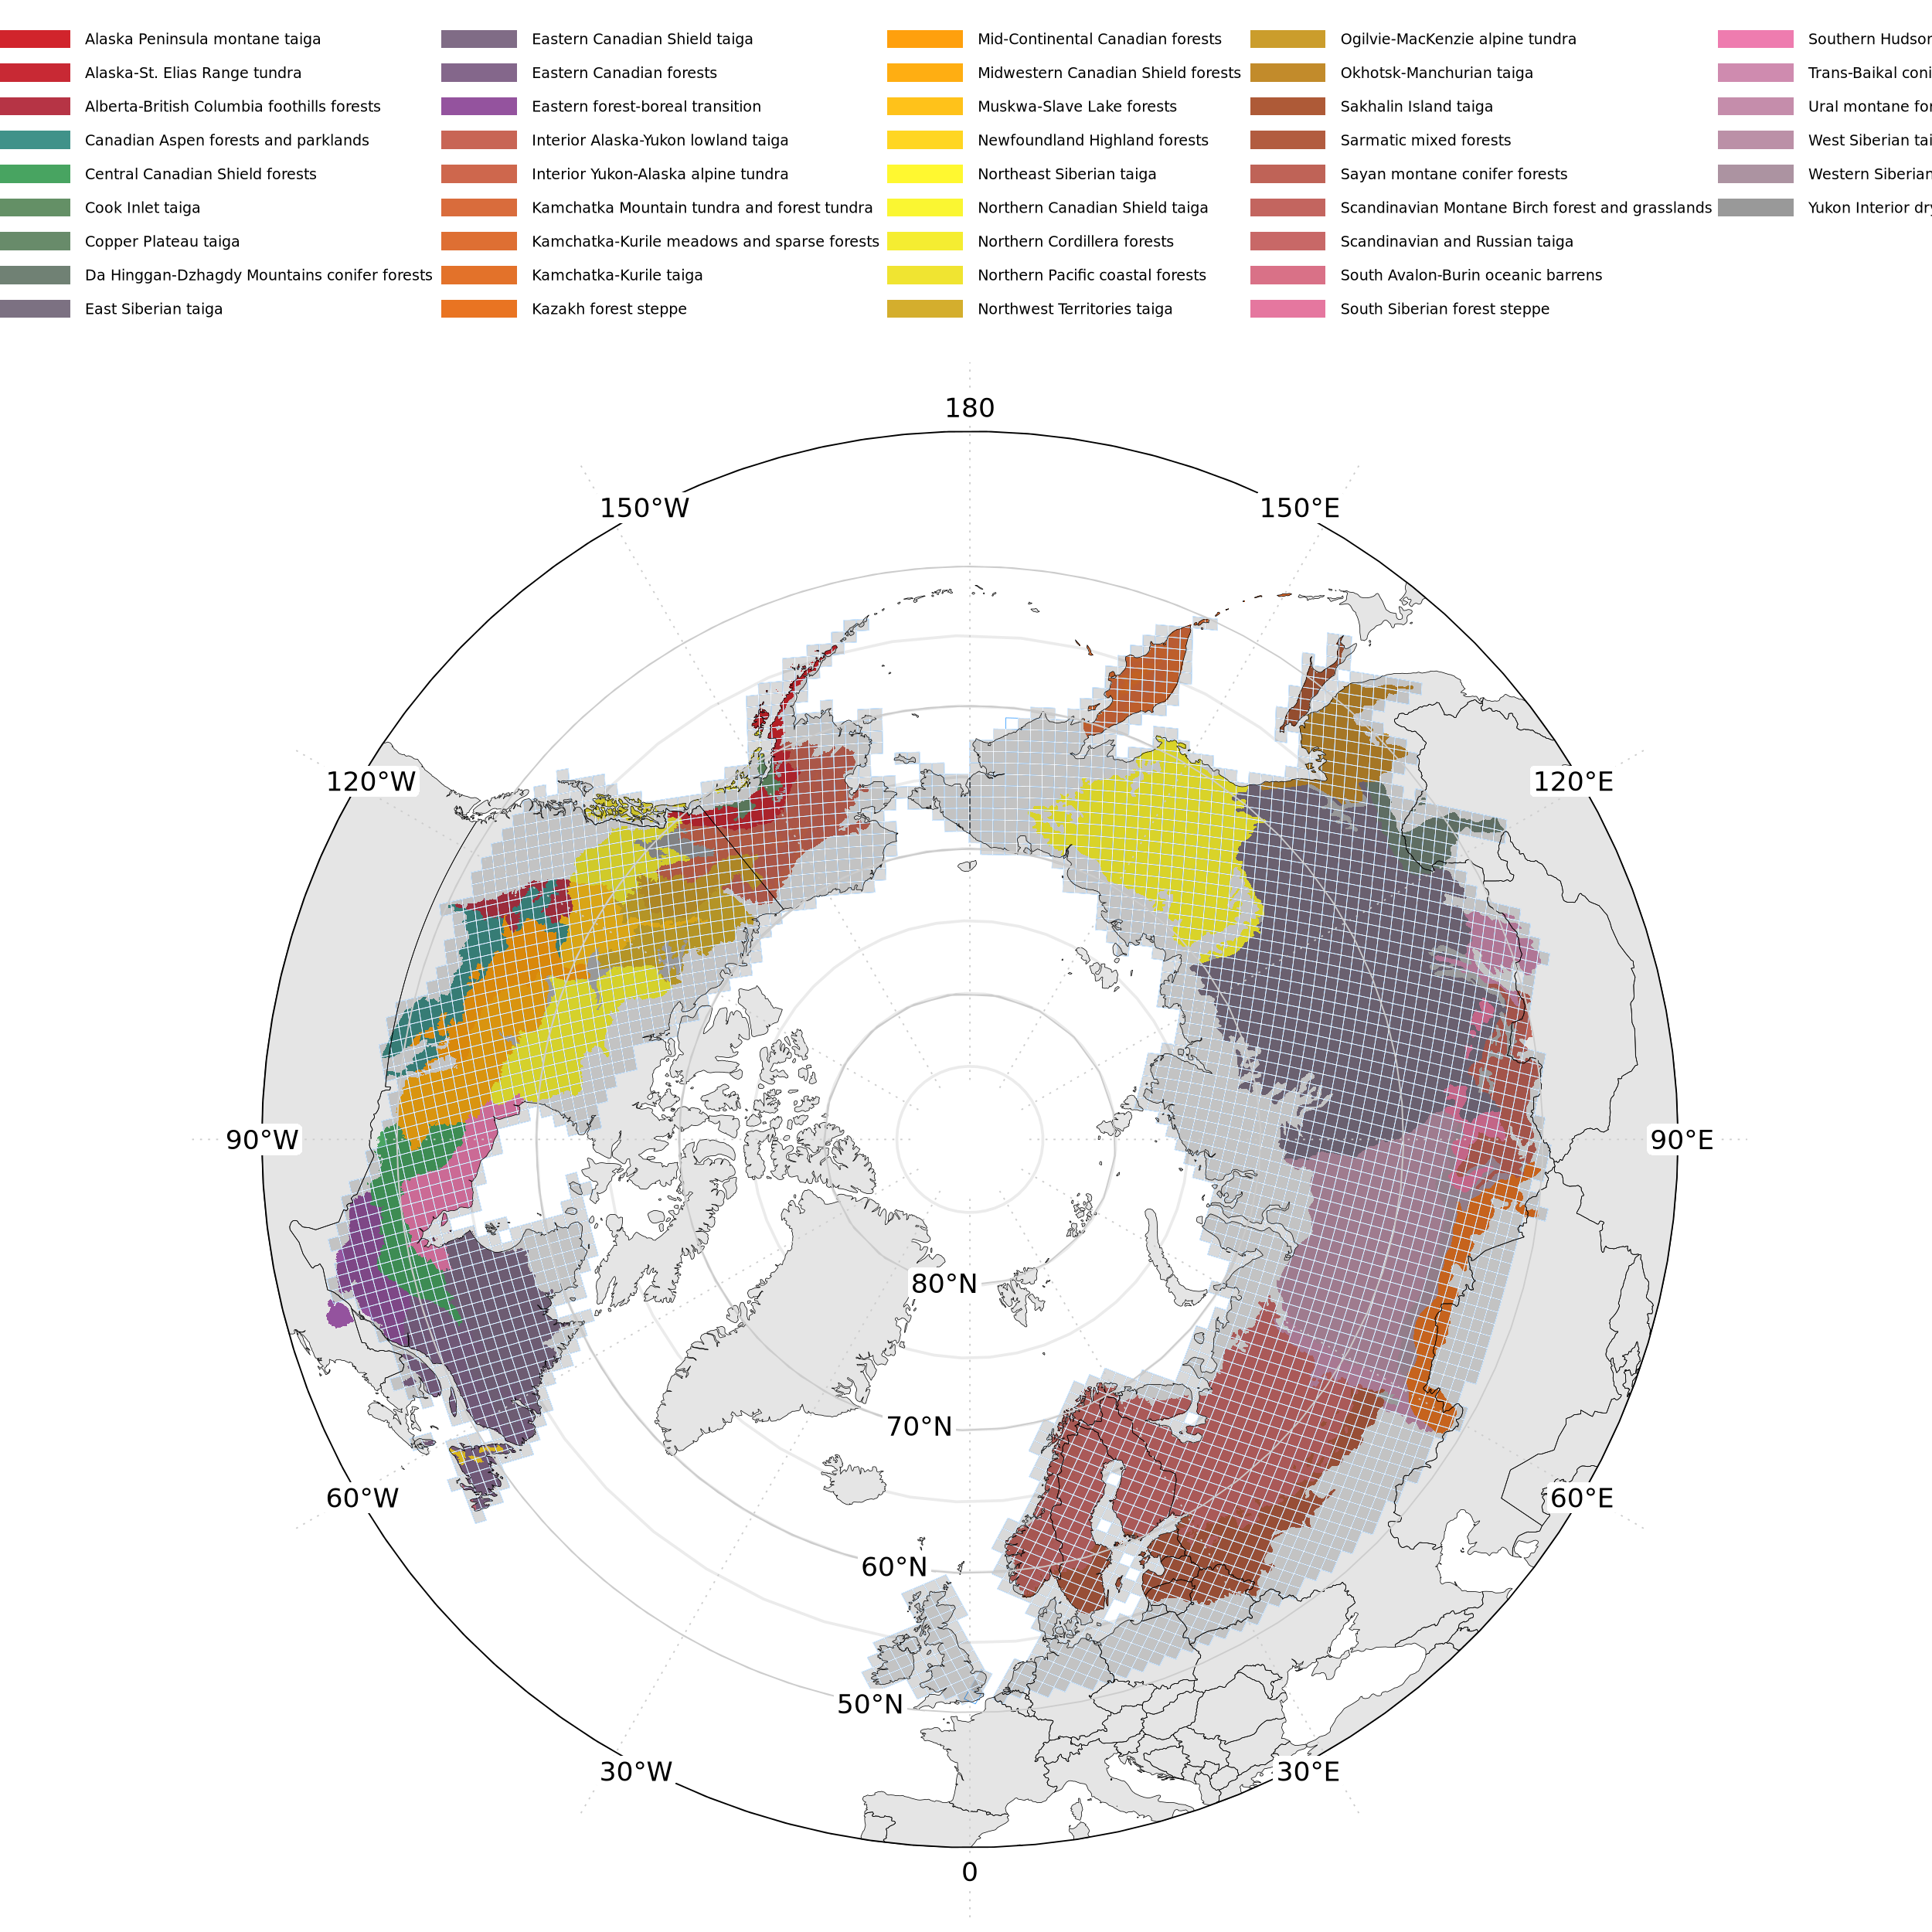

In [31]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 250)

colourCount = length(unique(wwf_ecoregions_in_summary$ecoregions_ECO_NAME))
print(paste0("Cluster count is: ",colourCount))
getPalette = colorRampPalette(brewer.pal(9, "Set1"))


ecoregion_colors <-getPalette(colourCount)
names(ecoregion_colors) <- levels(factor(wwf_ecoregions_in_summary$ecoregions_ECO_NAME))

m_boreal_tiles = DO_MAP_BOREAL_SP(MAP_EXTENT=ext,  
                     BOREAL_SHP_FN = wwf_circ_dis_fn,
                     LAYER_LIST = list(
                         geom_polygon(data=wwf_ecoregions_in_summary %>% filter(ecoregions_ECO_NAME %in% boreal_ecoregions$ECO_NAME), 
                                      aes(x=long, y=lat, group=group, fill=ecoregions_ECO_NAME), size=0.1),
                         scale_fill_grey(start=0.25, end=0, name=NULL), # the dark end
                         scale_fill_manual(values=ecoregion_colors, name="Ecoregion"),
                         geom_polygon(data=boreal_tiles_DAAC_gcs, aes(x=long, y=lat, group=group), size=0.1, fill=NA, color='dodgerblue'),
                         geom_polygon(data=boreal_tiles_DAAC_gcs %>% filter(tile_num %in% TILE_NUM_LIST), aes(x=long, y=lat, group=group), 
                                      alpha=0.15, size=0.1, fill='black', color='white')
                         #,geom_polygon(data = hydrobasin_si_lev02, aes(x = long, y = lat, group = group), size=0.1, fill=NA, color='black') 
                         #,
                         #, geom_text(data = boreal_tiles_DAAC_gcs %>% filter(tile_num %in% TILE_NUM_LIST) %>% group_by(tile_num) %>%
                         #      summarize(long = mean(long),
                         #                lat = mean(lat)),
                         #      aes(x = long, y = lat, label = tile_num), size = 2.5, fontface = "bold")
                     ) #, fill=NA
                    ) + 
    theme(legend.text=element_text(size=rel(0.5)))
m_boreal_tiles

In [32]:
geom_list_theme = list(
                    theme_bw() ,
                #theme(axis.text.x = element_blank()) ,
                theme(
                    #axis.text.x = element_text(angle=90),
                    legend.position = "top",
                    #legend.text = element_text(angle = 90, hjust = 1),
                    legend.spacing.x = unit(0.4, "cm"),
                    legend.margin = margin(t = 0, r = 0, b = 25, l = 0), # Add space for rotated text
                    plot.margin = margin(b = 30, t = 10, l = 10, r = 10),
                    plot.title = element_text(hjust = 0.5, face = "bold")
              ) 
    )
geom_list_bars_age = list(
            scale_fill_manual(values=age_colors, aesthetics = c("color", "fill"), #name='Age cohort'
                                 guide = guide_legend(
                  direction = "horizontal",
                  title = 'Age cohort (forest demography)',
                  title.position = "top",
                  label.position = "bottom",
                  label.hjust = 0.5,
                  label.vjust = 0.5,
                  keywidth = unit(1.0, "cm"),
                  keyheight = unit(0.4, "cm"),
                  nrow = 1
                        )
                ),
            geom_list_theme
            )
geom_list_color_trend = list(
        scale_fill_manual(values=trend_colors, aesthetics = c("color", "fill"), #name='1984-2020\ntree cover\ntrend class',
                             guide = guide_legend(
              direction = "horizontal",
              title = '1984-2020 tree cover trend class',
              title.position = "top",
              label.position = "bottom",
              label.hjust = 0.5,
              label.vjust = 0.5,
              keywidth = unit(1.2, "cm"),
              keyheight = unit(0.4, "cm"),
              nrow = 1
            )
    ),
    theme(
        #axis.text.x = element_blank(),
        legend.position = "top",
        #legend.text = element_text(angle = 90, hjust = 1),
        legend.spacing.x = unit(0.4, "cm"),
        legend.margin = margin(t = 0, r = 0, b = 25, l = 0), # Add space for rotated text
        plot.margin = margin(b = 30, t = 10, l = 10, r = 10),
        plot.title = element_text(hjust = 0.5, face = "bold")
      ) 
    )

## What is total C by age cohort in boreal

### need to get boreal only pixels - probably need a boreal/non-boreal flag based on vector
### can use !- 'NO TREND AVAILABLE' since that tells us where no stand age, thus not in boreal - but that vector was slightly different (less area)

In [36]:
fraction_realm_age = summary_df %>% 
    #drop_na() %>% 
    group_by(ecoregions_REALM, age_class) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), 
        Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), 
        Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
fraction_realm_age

`summarise()` has grouped output by 'ecoregions_REALM'. You can override using
the `.groups` argument.


ecoregions_REALM,age_class,Total_C,Fraction_area,Percent_area_round,Fraction_C,Percent_C_round
<chr>,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PA,non-forest,6.3865651,1978.936532,197893.7,1434.554009,143455.4
PA,1-20,3.0482126,140.161168,14016.1,147.288227,14728.8
PA,21-36,0.2772434,11.408247,1140.8,18.014159,1801.4
PA,37-60,1.1048958,40.303268,4030.3,68.744080,6874.4
PA,61-80,3.2914796,94.104511,9410.5,161.365507,16136.6
PA,81-100,6.5819010,213.857195,21385.7,294.858391,29485.8
PA,101-150,20.6428928,714.174298,71417.4,1015.870219,101587.0
PA,>150,2.4817609,101.104510,10110.5,153.379015,15337.9
NA,non-forest,2.6702134,814.557101,81455.7,617.589897,61759.0


## Identify Boreal-only data
#### with filter based on presence of TerraPulse trends

In [37]:
length(levels(factor(boreal_ecoregions$ECO_NAME)))

[1] 42

In [38]:
dim(summary_df)

[1] 374280     37

In [39]:
# This was just a temp way of filtering to 'boreal only' - b/c we only have trends for boreal pixels in the TP boreal polygon
dim(summary_df %>% filter(trend_class != 'no trend\navailable'))

[1] 347091     37

In [40]:
smry_tiles = summary_df %>%
    group_by(ID) %>%
    summarize(
        n_groups = n()
        )
dim(smry_tiles)

[1] 4950    2

#### with filter based on boreal + transitional ecoregions

In [34]:
# This is a better way to filter to 'boreal' using summaries of from only boreal ecoregions
smry_boreal_only_df = summary_df %>% 
            #filter(trend_class != 'no trend\navailable') %>%
            filter(ecoregions_ECO_NAME %in% levels(factor(boreal_ecoregions$ECO_NAME))) %>%
            mutate(ecoregions_REALM = replace_na(as.character(ecoregions_REALM), "NA")) %>%
            mutate(ecoregions_REALM = as.factor(recode(ecoregions_REALM,
                          "NA" = "Boreal North America",
                          "PA" = "Boreal Eurasia")),
                   domain = "Circumpolar Boreal"
                   )

smry_tiles = smry_boreal_only_df %>%
    group_by(ID) %>%
    summarize(
        n_groups = n()
        )
dim(smry_tiles)

[1] 3042    2

In [35]:
levels(factor(smry_boreal_only_df$ecoregions_REALM))

[1] "Boreal Eurasia"       "Boreal North America"

### Columns from summaries

+ `total_carbon_Pg` (from `calculate_area_and_total_carbon()`) : table based, from final pixels;  the mean C Stock for the group
+ `total_carbon_Pg_mean` (from `calculate_monte_carlo_totals()`) : raster based; from stack of n sims before final pixels; the mean, std, etc value from the mask (for a group of classes) of the total (sum) carbon vector of length n of each carbon raster in stack of n rasters 

In [36]:
smry_age_class_realm = smry_boreal_only_df %>% 
    group_by(ecoregions_REALM, age_class) %>% summarize(
            sum_total_C_Pg = sum(total_carbon_Pg),
        sum_total_C_Pg_mean = sum(total_carbon_Pg_mean),
        sum_total_C_Pg_std = sum(total_carbon_Pg_std),
        sum_total_C_Pg_ci_lower = sum(total_carbon_Pg_ci_lower),
        sum_total_C_Pg_ci_upper = sum(total_carbon_Pg_ci_upper),
        sum_total_C_Pg_pi_lower = sum(total_carbon_Pg_pi_lower),
        sum_total_C_Pg_pi_upper = sum(total_carbon_Pg_pi_upper)
                                            )
smry_age_class_realm

`summarise()` has grouped output by 'ecoregions_REALM'. You can override using
the `.groups` argument.


ecoregions_REALM,age_class,sum_total_C_Pg,sum_total_C_Pg_mean,sum_total_C_Pg_std,sum_total_C_Pg_ci_lower,sum_total_C_Pg_ci_upper,sum_total_C_Pg_pi_lower,sum_total_C_Pg_pi_upper
<fct>,<ord>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Boreal Eurasia,non-forest,2.78401628,2.78404363,1.141590e-03,2.78371919,2.78436806,2.78174951,2.78633774
Boreal Eurasia,1-20,2.48691175,2.48692228,1.044105e-03,2.48662555,2.48721901,2.48482407,2.48902049
Boreal Eurasia,21-36,0.09879336,0.09879351,1.207560e-04,0.09875919,0.09882782,0.09855084,0.09903617
Boreal Eurasia,37-60,0.46843529,0.46843769,2.444463e-04,0.46836822,0.46850716,0.46794646,0.46892892
Boreal Eurasia,61-80,1.74253702,1.74254712,4.872418e-04,1.74240865,1.74268560,1.74156797,1.74352627
Boreal Eurasia,81-100,4.47722700,4.47723873,1.044404e-03,4.47694191,4.47753555,4.47513992,4.47933754
Boreal Eurasia,101-150,18.09634453,18.09640936,2.240558e-03,18.09577260,18.09704612,18.09190679,18.10091193
Boreal Eurasia,>150,2.14438048,2.14438868,4.143499e-04,2.14427093,2.14450644,2.14355602,2.14522135
Boreal North America,non-forest,0.86981451,0.86982072,6.402689e-04,0.86963875,0.87000268,0.86853405,0.87110739


In [40]:
sum(smry_age_class_realm$sum_total_C_Pg) * 2

[1] 79.28085

In [38]:
sum(smry_age_class_realm$sum_total_C_Pg_mean)

[1] 39.6406

In [39]:
sum(smry_age_class_realm$sum_total_C_Pg_ci_lower)

[1] 39.63774

In [41]:
names(smry_boreal_only_df)

[1] "ecoregions_REALM"         "ecoregions_ECO_NAME"     
 [3] "age_class"                "age_cohort"              
 [5] "trend_class"              "pvalue_class"            
 [7] "deciduous_class"          "pixel_count"             
 [9] "area_ha"                  "biomass_mean"            
[11] "biomass_std"              "biomass_count"           
[13] "age_mean"                 "age_std"                 
[15] "carbon_mean"              "carbon_std"              
[17] "carbon_sum"               "carbon_acc_mean"         
[19] "carbon_acc_std"           "carbon_acc_ci_lower_mean"
[21] "carbon_acc_ci_upper_mean" "carbon_acc_pi_lower_mean"
[23] "carbon_acc_pi_upper_mean" "total_carbon_Pg"         
[25] "total_carbon_Pg_mean"     "total_carbon_Pg_std"     
[27] "total_carbon_Pg_ci_lower" "total_carbon_Pg_ci_upper"
[29] "total_carbon_Pg_pi_lower" "total_carbon_Pg_pi_upper"
[31] "ID"                       "fractional_area"         
[33] "fractional_C"             "ymax"                    
[35] "ymax_C"                   "ymin"                    
[37] "ymin_C"                   "domain"

#### Monte Carlo Age Class C totals and uncertainties

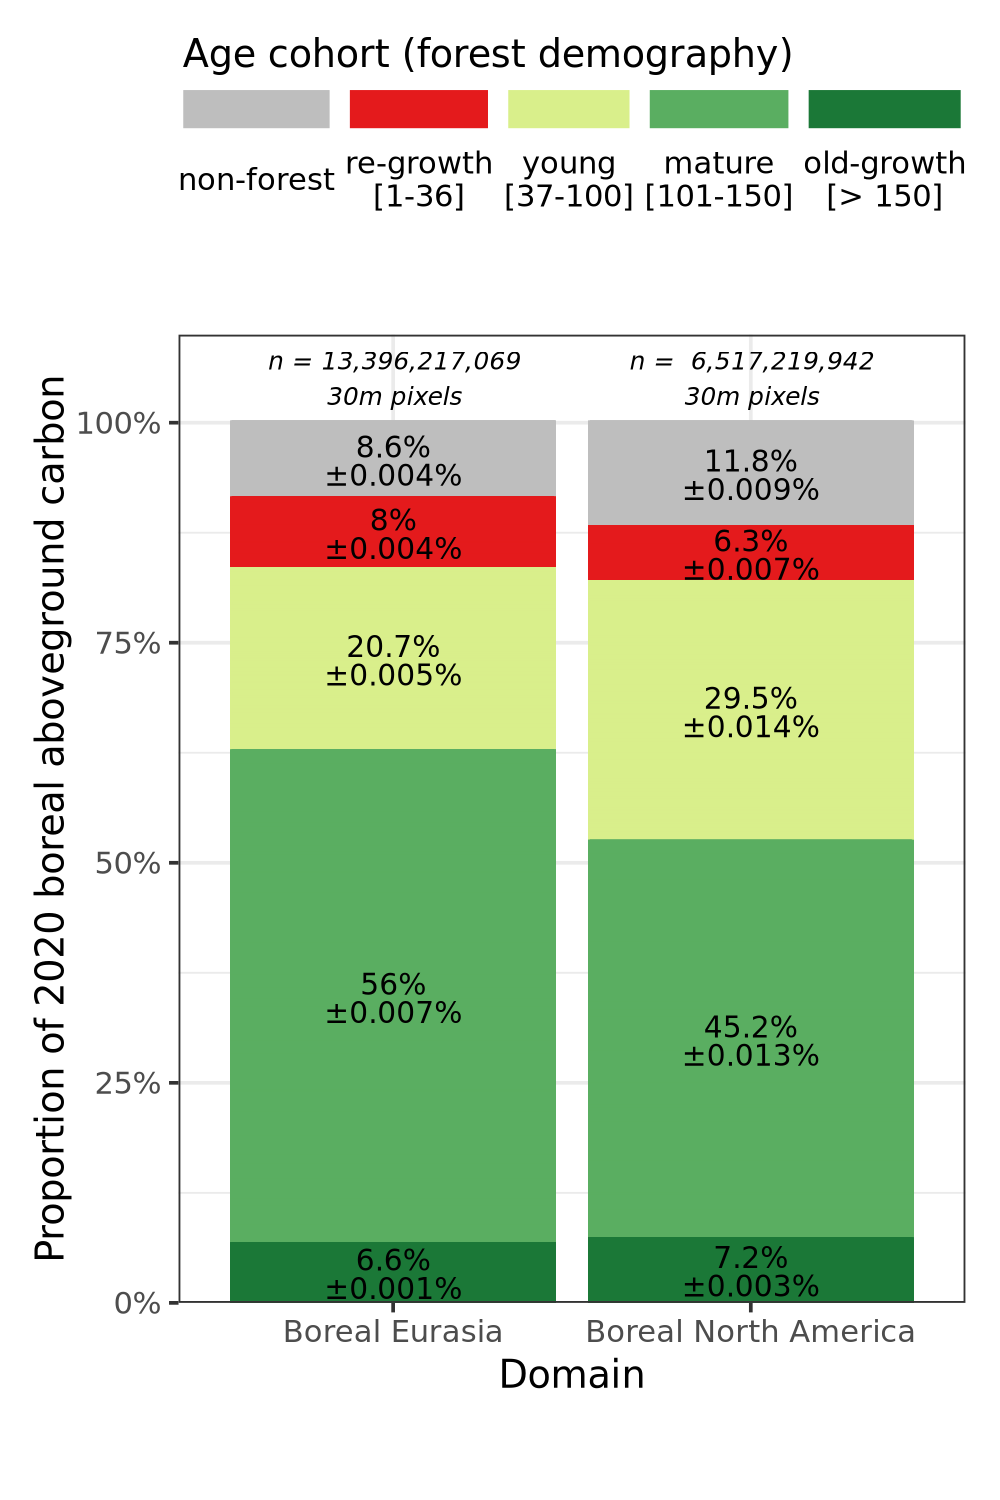

In [105]:
options(repr.plot.width = 4, repr.plot.height = 6, repr.plot.res = 250)

# Calculate text data with standard deviation
text_data <- smry_boreal_only_df %>%
  group_by(ecoregions_REALM, age_cohort) %>%
  summarise(
    carbon_sum = sum(total_carbon_Pg_mean, na.rm = TRUE),
    carbon_std = sum(total_carbon_Pg_std, na.rm = TRUE),
    n_pix = sum(pixel_count),
    .groups = "drop"
  ) %>%
  group_by(ecoregions_REALM) %>%
  arrange(ecoregions_REALM, desc(age_cohort)) %>%
  mutate(
    carbon_total = sum(carbon_sum),
    total_std = sum(carbon_std),
    
    # Calculate proportions
    proportion = carbon_sum / carbon_total,
    percentage = round(proportion * 100, 1),
    
    # Convert std to percentage
    std_prop = carbon_std / carbon_total, 
    std_percentage = round(std_prop * 100, 3),
    
    # Position text
    pos_y = cumsum(proportion) - 0.5 * proportion,
    
    # Create label with ± std
    label_text = paste0(percentage, "%\n\u00B1", std_percentage, "%")
  ) %>%
  ungroup()

# Calculate n_pix totals for each ecoregion (for top labels)
npix_data <- smry_boreal_only_df %>%
  group_by(ecoregions_REALM) %>%
  summarise(
    total_n_pix = sum(pixel_count),
    .groups = "drop"
  ) %>%
  mutate(
    y_pos = 1.02,  # Position slightly above the top of the bar
    label_text = paste0("n = ", format(total_n_pix, big.mark = ","),"\n30m pixels")
  )

ggplot(smry_boreal_only_df) +
    geom_bar(aes(x = ecoregions_REALM, y = total_carbon_Pg_mean, fill = age_cohort, color = age_cohort), 
             stat = "identity", position = "fill") +
    # Add segment labels
    geom_text(
      data = text_data,
      aes(x = ecoregions_REALM, y = pos_y, label = label_text),
      color = "black",
      size = 3.0,
      lineheight = 0.8
    ) +
    # Add n_pix labels at the top of each bar
    geom_text(
      data = npix_data,
      aes(x = ecoregions_REALM, y = y_pos, label = label_text),
      color = "black",
      fontface = "italic",
      size = 2.5,
      vjust = 0
    ) +
    labs(x = "Domain",
         y = "Proportion of 2020 boreal aboveground carbon",
         fill = "Age Class") +
    scale_y_continuous(labels = scales::percent, 
                       limits = c(0, 1.1),  # Extend y-axis to accommodate top labels
                       expand = c(0, 0)) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    geom_list_bars_age

`summarise()` has grouped output by 'ecoregions_REALM'. You can override using
the `.groups` argument.
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


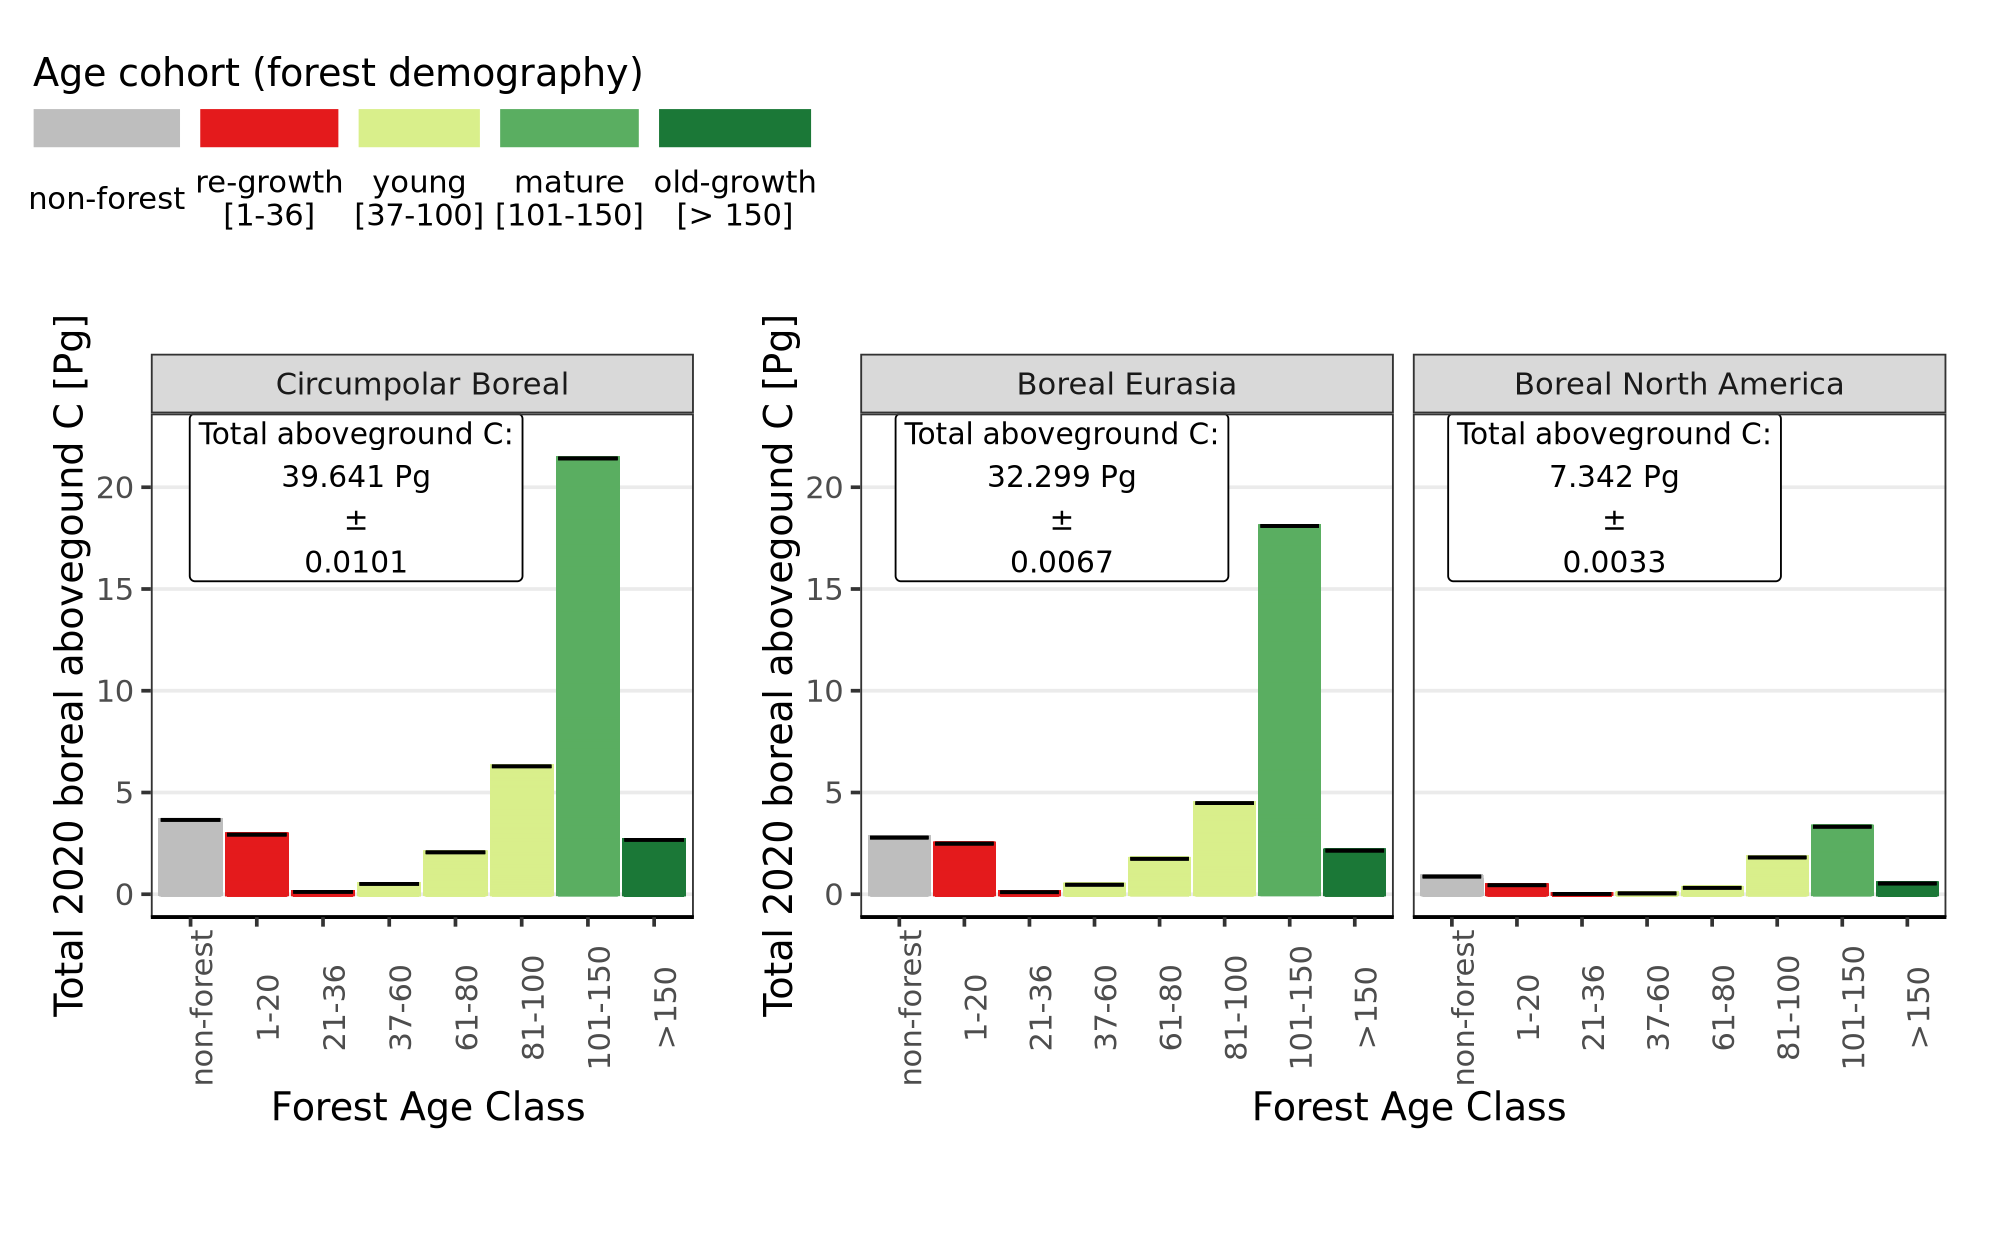

In [49]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 250)

# Boreal total

smry_boreal = smry_boreal_only_df %>% 
    summarize(
            sum_total_C_Pg_mean = sum(total_carbon_Pg_mean),
        sum_total_C_Pg_std = sum(total_carbon_Pg_std)
                )
smry_age_class_boreal = smry_boreal_only_df %>% 
    group_by(age_class) %>% 
    summarize(
        sum_total_C_Pg = sum(total_carbon_Pg),
        sum_total_C_Pg_mean = sum(total_carbon_Pg_mean),
        sum_total_C_Pg_std = sum(total_carbon_Pg_std),
        sum_total_C_Pg_ci_lower = sum(total_carbon_Pg_ci_lower),
        sum_total_C_Pg_ci_upper = sum(total_carbon_Pg_ci_upper),
        sum_total_C_Pg_pi_lower = sum(total_carbon_Pg_pi_lower),
        sum_total_C_Pg_pi_upper = sum(total_carbon_Pg_pi_upper)
                )
# Realm totals
smry_realm = smry_boreal_only_df %>% 
    group_by(ecoregions_REALM) %>% 
    summarize(
            sum_total_C_Pg_mean = sum(total_carbon_Pg_mean),
            sum_total_C_Pg_std = sum(total_carbon_Pg_std),
                )
smry_age_class_realm = smry_boreal_only_df %>% 
    group_by(ecoregions_REALM, age_class) %>% 
    summarize(
        sum_total_C_Pg = sum(total_carbon_Pg),
        sum_total_C_Pg_mean = sum(total_carbon_Pg_mean),
        sum_total_C_Pg_std = sum(total_carbon_Pg_std),
        sum_total_C_Pg_ci_lower = sum(total_carbon_Pg_ci_lower),
        sum_total_C_Pg_ci_upper = sum(total_carbon_Pg_ci_upper),
        sum_total_C_Pg_pi_lower = sum(total_carbon_Pg_pi_lower),
        sum_total_C_Pg_pi_upper = sum(total_carbon_Pg_pi_upper)
                )

p_bars_age = ggplot() +
    geom_bar(smry_boreal_only_df
             , mapping=aes( x=age_class, y=(total_carbon_Pg_mean), fill=age_cohort, color=age_cohort) , stat='identity') + # for a regular bar plot - fast  
    geom_list_bars_age +
    lims(y=c(0,22.5))+
    labs(y='Total 2020 boreal abovegound C [Pg]', x=' Forest Age Class') +    
    theme(axis.text.x = element_text(angle=90),
         panel.grid.major.x = element_blank(),
        panel.grid.minor = element_blank(),
          axis.line.x = element_line(color = "black", size = 0.50, linetype = "solid")
         ) +
    facet_wrap(~domain)
p_bars_age_circumpolar = p_bars_age + 
    geom_errorbar(data=smry_age_class_boreal, mapping=aes( x=age_class, ymin=sum_total_C_Pg_pi_lower, ymax=sum_total_C_Pg_pi_upper, group=age_class)) +
        geom_label(data=smry_boreal, mapping=aes(
            x = 3.5,  # Position text in center
            y = Inf,    # Any value works as we're not using this dimension
            label = paste0("Total aboveground C:\n", round(sum_total_C_Pg_mean, 3), " Pg\n±\n", round(sum_total_C_Pg_std, 4)
              )), size = 3, vjust=1)

p_bars_realm_age = p_bars_age +
    geom_errorbar(data=smry_age_class_realm, mapping=aes( x=age_class, ymin=sum_total_C_Pg_pi_lower, ymax=sum_total_C_Pg_pi_upper, group=age_class)) +
    #text_total_C_tile_decid +
    #geom_text(data=fraction_age_decid, mapping=aes(x=age_cohort, y=Total_C, label=paste0(Percent_C_round,'%\n(',Percent_area_round,'%)')), size=2, vjust=-1) +
    geom_label(data=smry_realm, mapping=aes(
            x = 3.5,  # Position text in center
            y = Inf,    # Any value works as we're not using this dimension
            label = paste0("Total aboveground C:\n", round(sum_total_C_Pg_mean, 3), " Pg\n±\n", round(sum_total_C_Pg_std, 4)
              )), size = 3, vjust=1) +
    facet_wrap(~ecoregions_REALM, ncol=2)

layout <- "ABB"
(p_bars_age_circumpolar | p_bars_realm_age + theme(legend.position = "none") ) + plot_layout(design = layout)

## What is C accum rate by age cohort in boreal (this is for `forest` pixels only)

Warning message:
“Removed 3951 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 3951 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


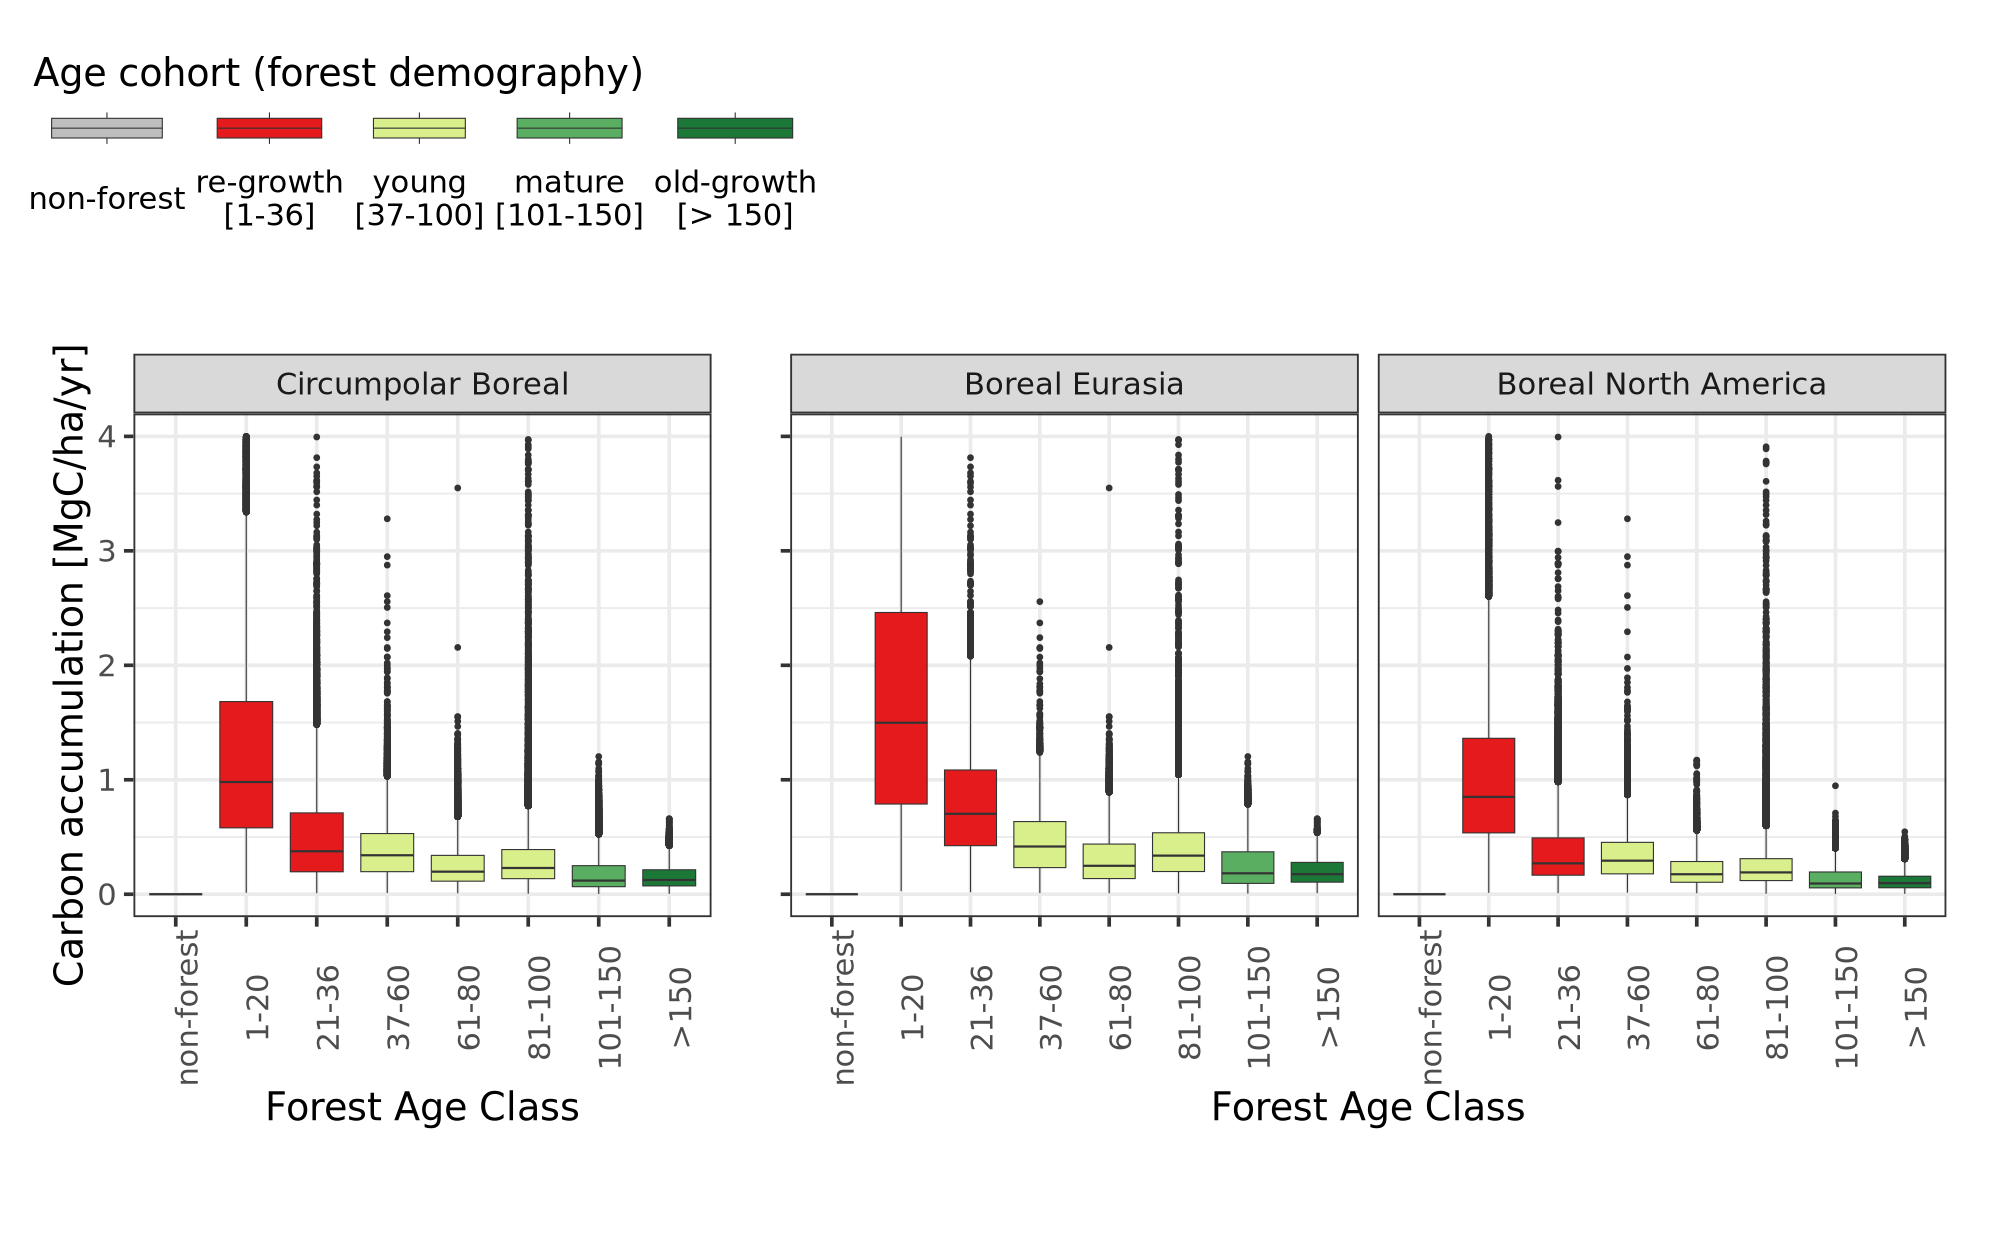

In [53]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 250)

p_cacc_ageclass = ggplot(smry_boreal_only_df
      ) +
    geom_boxplot(aes(x = age_class ,y = carbon_acc_mean, fill=age_cohort),
                   position = position_dodge(width = 0.8), size=0.15, outlier.size = 0.25) +
    lims(y=c(0,4)) +
    labs(y = 'Aboveground carbon accumulation\n[MgC/ha/yr]', x='Forest Age Class') +
    theme_bw() +
    geom_list_bars_age +
    theme(axis.text.x = element_text(angle=90))

layout <- "ABB"
(p_cacc_ageclass  + facet_wrap(~domain)| p_cacc_ageclass + facet_wrap(~ecoregions_REALM, ncol=2)  + theme(legend.position = "none", axis.text.y = element_blank(), axis.title.y = element_blank())) + plot_layout(design = layout )

Warning message:
“Removed 3926 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 3926 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


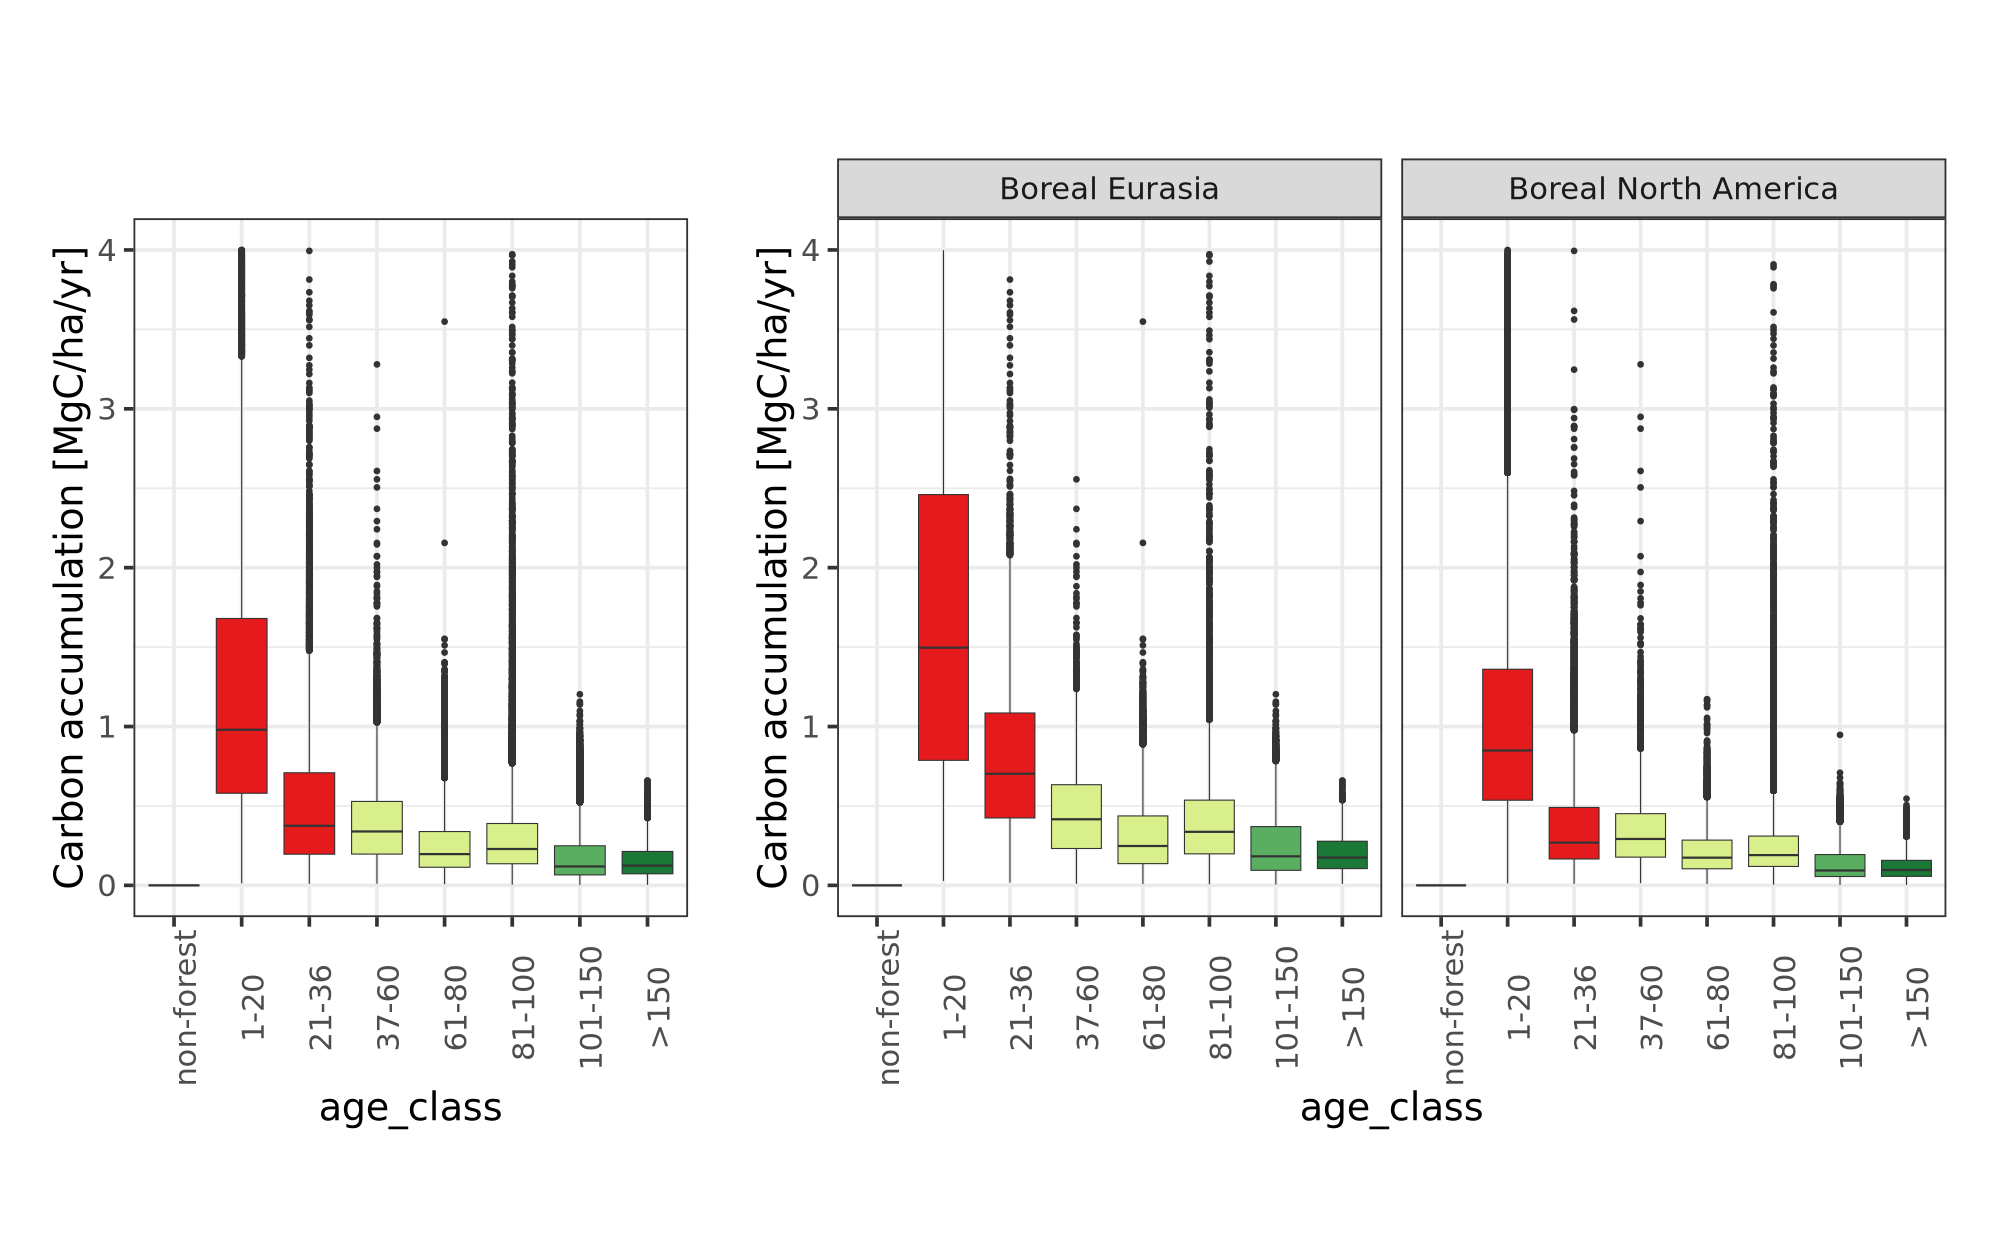

In [373]:
# First, remove the legend from individual plots
p_cacc_ageclass = ggplot(smry_boreal_only_df) +
    geom_boxplot(aes(x = age_class, y = carbon_acc_mean, fill = age_cohort),
                 position = position_dodge(width = 0.8), size=0.15, outlier.size = 0.25) +
    lims(y = c(0, 4)) +
    labs(y = 'Carbon accumulation [MgC/ha/yr]') +
    theme_bw() +
    geom_list_bars_age +
    theme(axis.text.x = element_text(angle = 90),
          legend.position = "none")  # Remove individual legend

# Create the faceted plot without legend
p_faceted = p_cacc_ageclass + 
    facet_wrap(~ecoregions_REALM, ncol = 2) +
    theme(legend.position = "none")  # Remove individual legend

# Update layout to include legend area on top
layout <- "
  LLL
  ABB
"

# Combine with legend positioned above
final_plot <-  p_cacc_ageclass + p_faceted + 
    plot_layout(design = layout, guides = 'collect',
                heights = c(0.15, 1))  # Legend takes 15% of height

print(final_plot)

In [85]:
colnames(smry_boreal_only_df)

[1] "ecoregions_REALM"         "ecoregions_ECO_NAME"     
 [3] "age_class"                "age_cohort"              
 [5] "trend_class"              "pvalue_class"            
 [7] "deciduous_class"          "pixel_count"             
 [9] "area_ha"                  "biomass_mean"            
[11] "biomass_std"              "biomass_count"           
[13] "age_mean"                 "age_std"                 
[15] "carbon_mean"              "carbon_std"              
[17] "carbon_sum"               "carbon_acc_mean"         
[19] "carbon_acc_std"           "carbon_acc_ci_lower_mean"
[21] "carbon_acc_ci_upper_mean" "carbon_acc_pi_lower_mean"
[23] "carbon_acc_pi_upper_mean" "total_carbon_Pg"         
[25] "total_carbon_Pg_mean"     "total_carbon_Pg_std"     
[27] "total_carbon_Pg_ci_lower" "total_carbon_Pg_ci_upper"
[29] "total_carbon_Pg_pi_lower" "total_carbon_Pg_pi_upper"
[31] "ID"                       "fractional_area"         
[33] "fractional_C"             "ymax"                    
[35] "ymax_C"                   "ymin"                    
[37] "ymin_C"                   "domain"

Warning message:
“Removed 3951 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


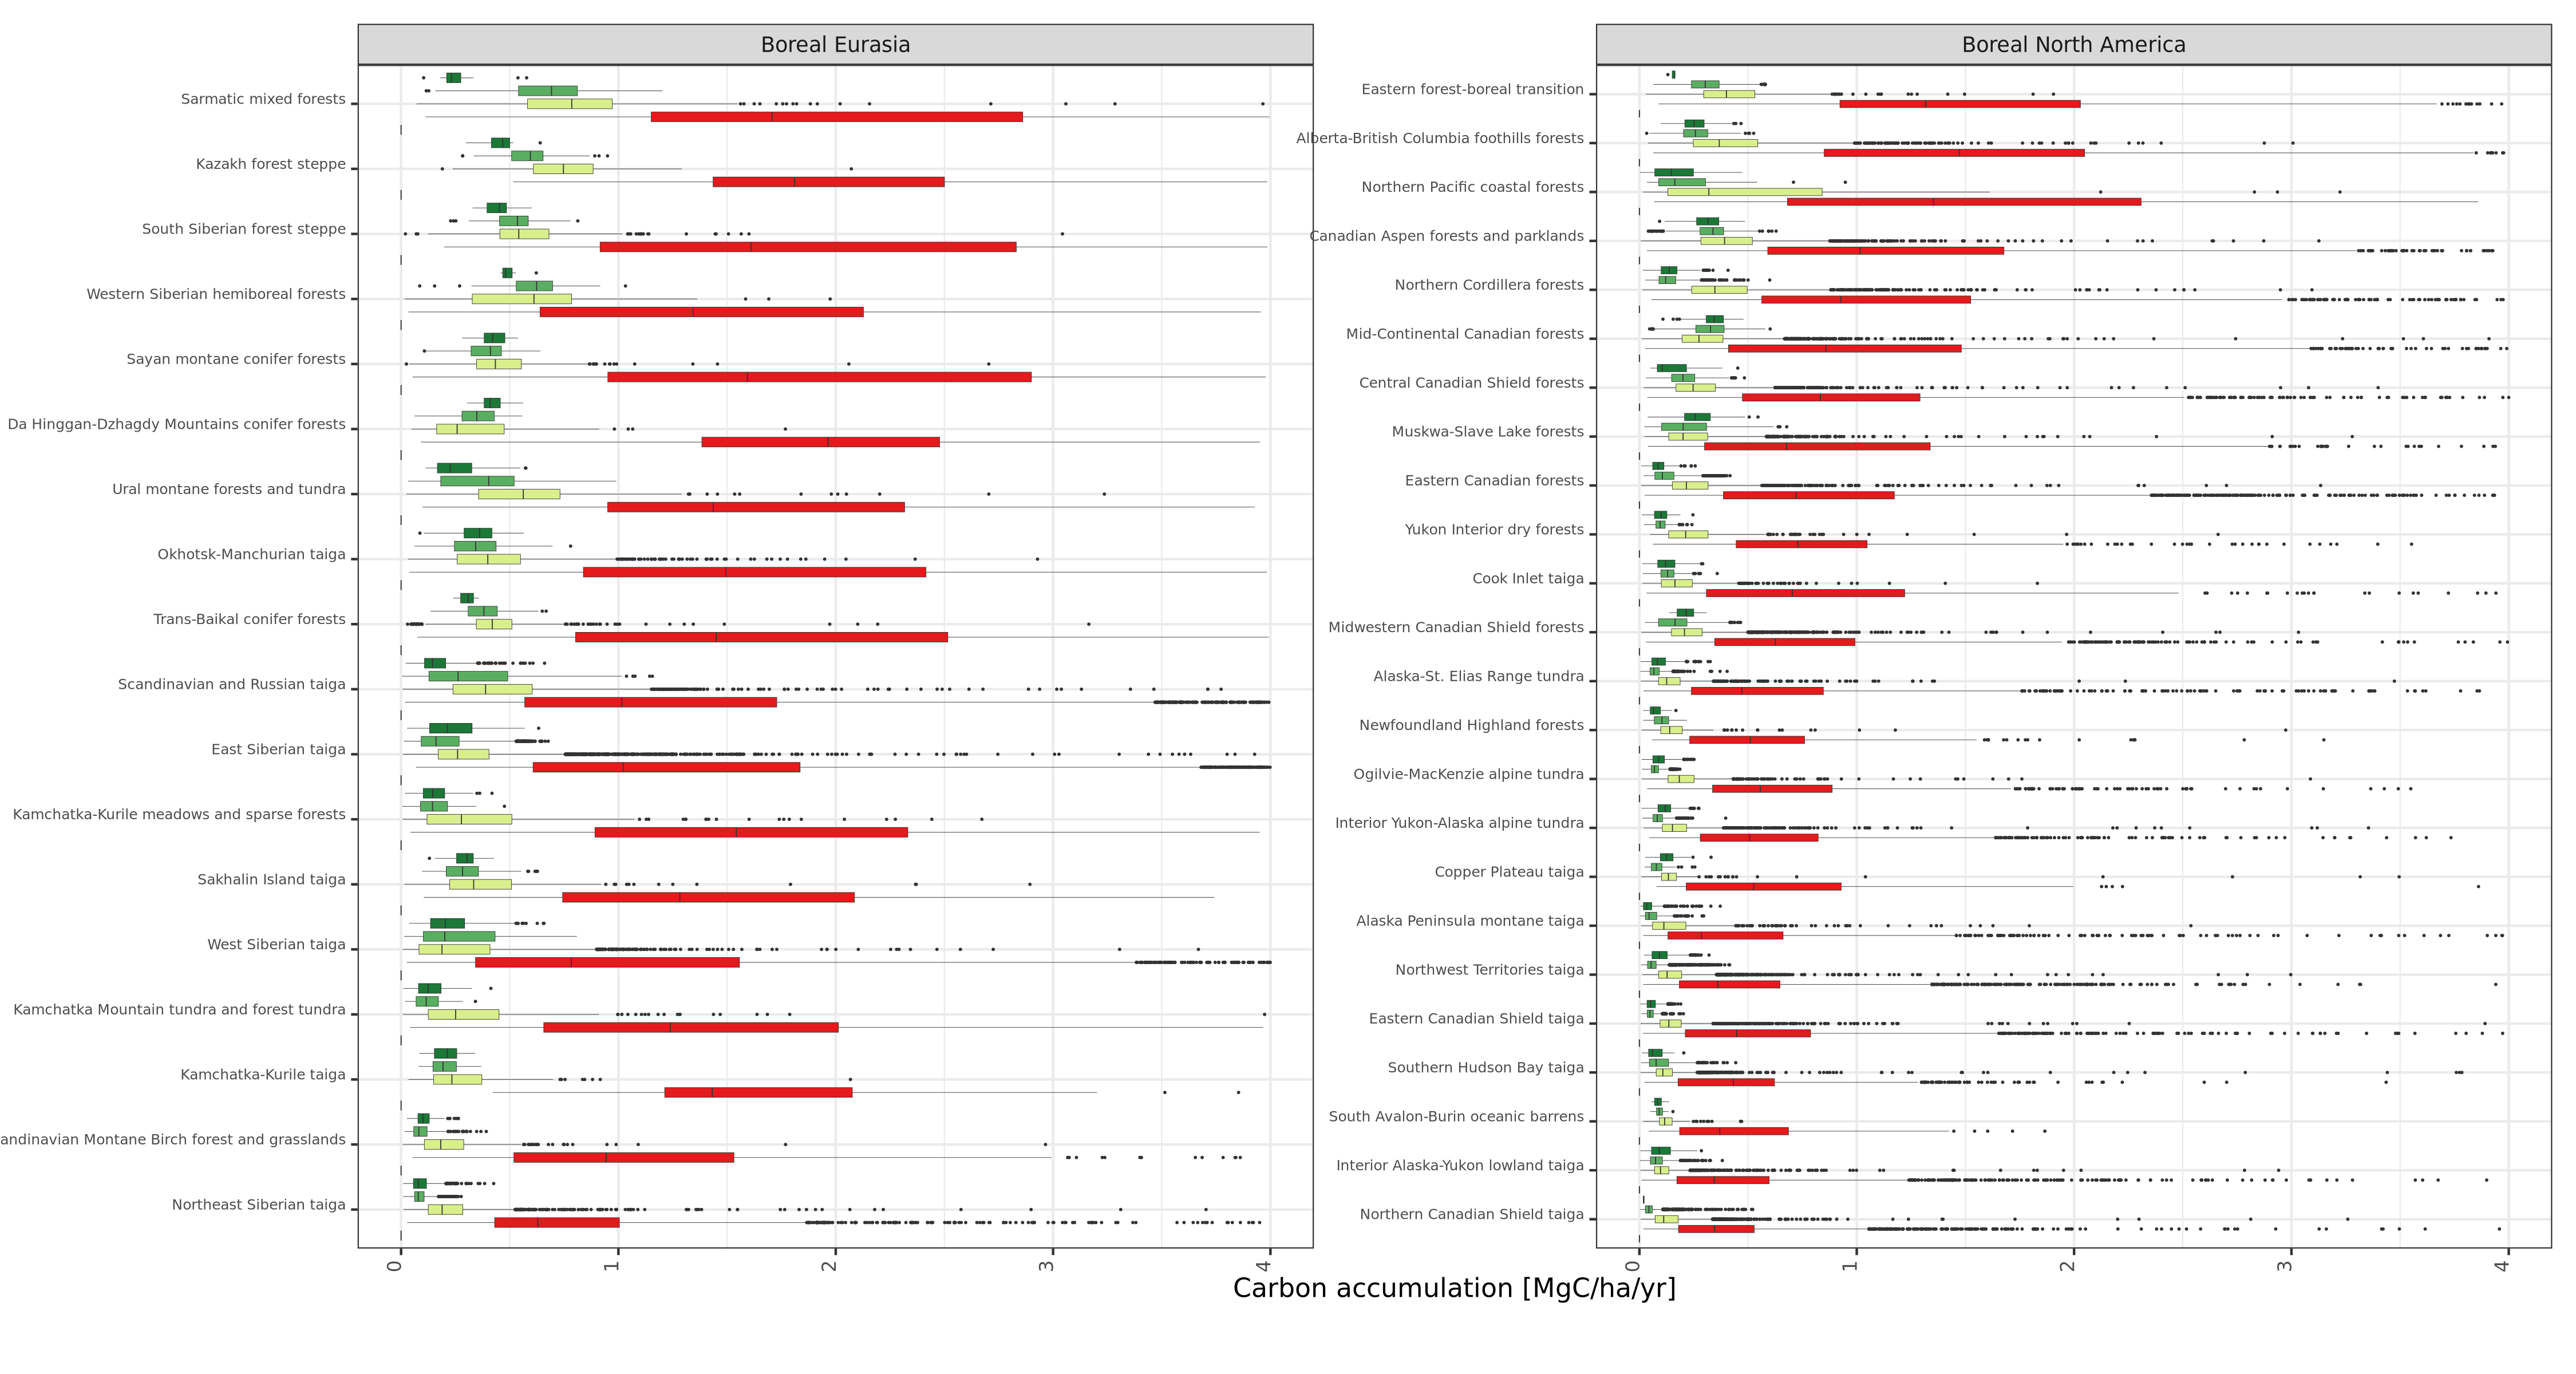

In [103]:
options(repr.plot.width = 15, repr.plot.height = 8, repr.plot.res = 300)

ggplot(smry_boreal_only_df) +
    geom_boxplot(aes(x = reorder(ecoregions_ECO_NAME, carbon_acc_mean), 
                   y = carbon_acc_mean, 
                   fill = age_cohort
                    #, group=ecoregions_ECO_NAME
                    )
               , position=position_dodge(1.0), size=0.1, outlier.size=0
              ) +
    lims(y = c(0, 4)) +
    labs(y = 'Abovegound carbon accumulation\n[MgC/ha/yr]', x=NULL) +
    theme_bw() +
    geom_list_bars_age +
    theme(axis.text.x = element_text(size=8, angle = 90, hjust=1, vjust=0),
          axis.text.y = element_text(size=6, hjust=1, vjust=0),
          legend.position = "none") +
    facet_wrap(~ecoregions_REALM, ncol=2, scales='free_y') + coord_flip()

Warning message:
“Removed 3926 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


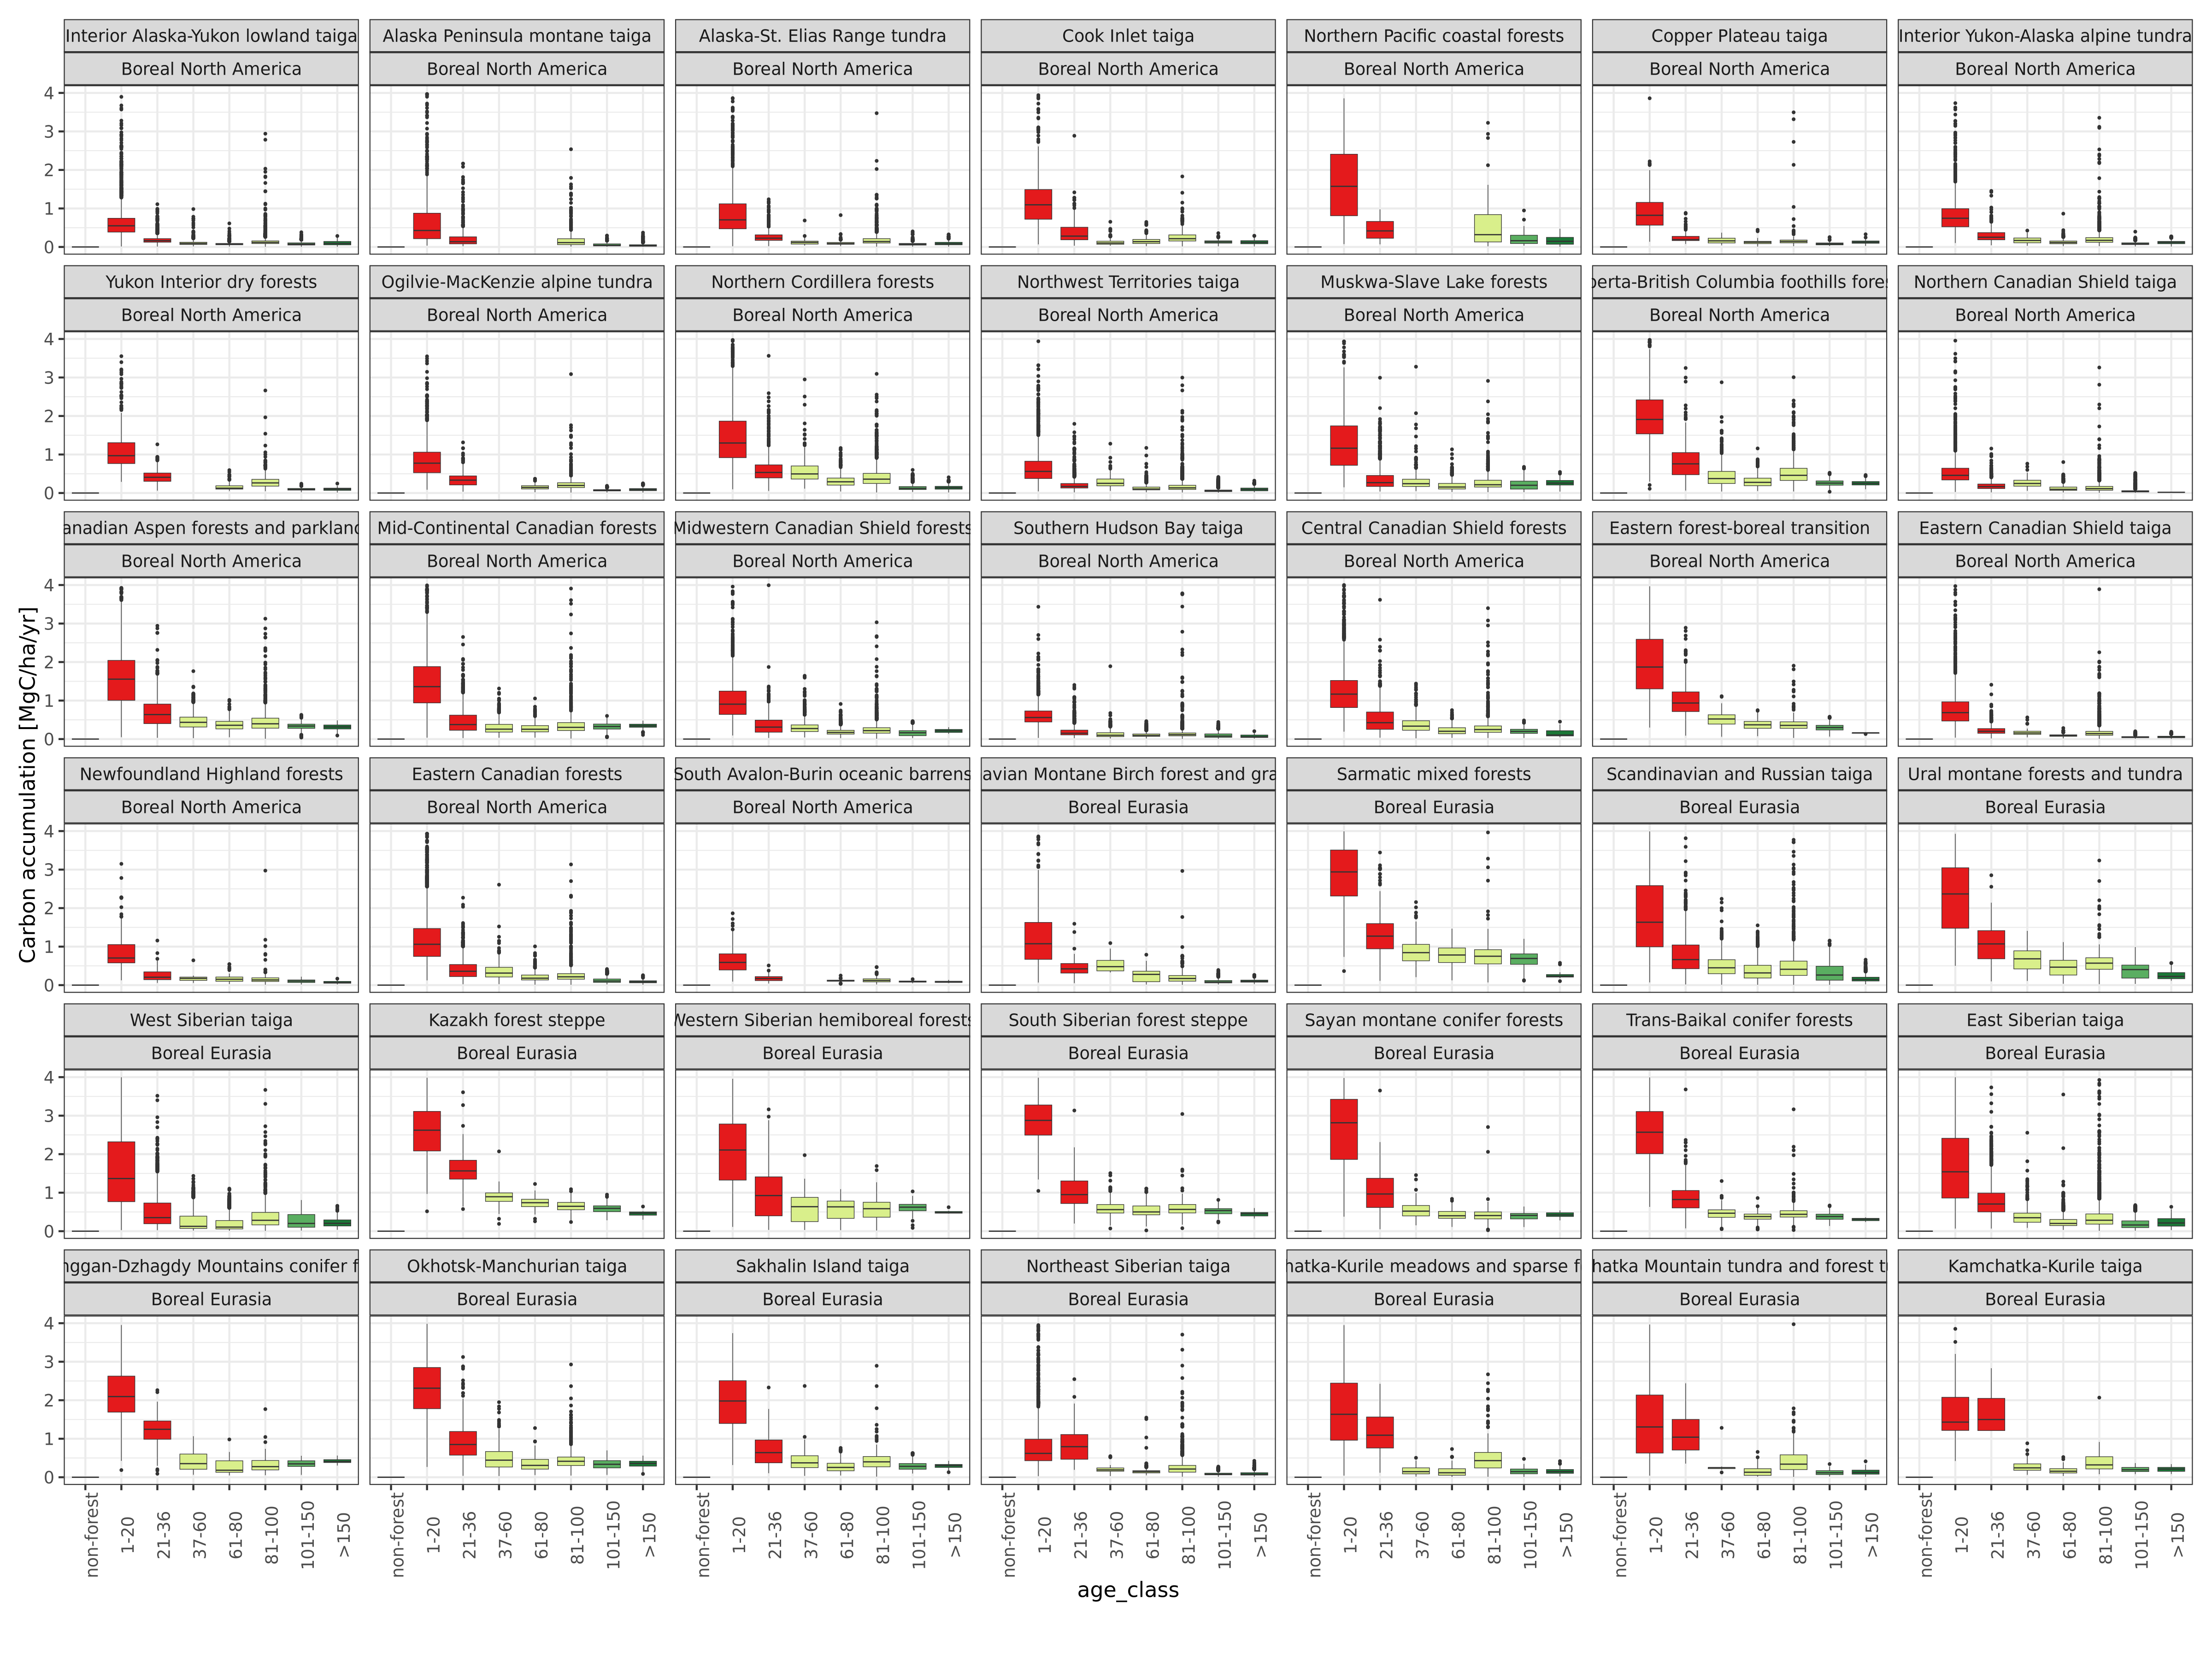

In [395]:
options(repr.plot.width = 16, repr.plot.height = 12, repr.plot.res = 300)

ggplot(smry_boreal_only_df) +
    geom_boxplot(aes(x = age_class, y = carbon_acc_mean, fill = age_cohort),
                 position = position_dodge(width = 0.8), size=0.15, outlier.size = 0.25) +
    lims(y = c(0, 4)) +
    labs(y = 'Carbon accumulation [MgC/ha/yr]') +
    theme_bw() +
    geom_list_bars_age +
    theme(axis.text.x = element_text(angle = 90),
          legend.position = "none")  +
    facet_wrap(~ecoregions_ECO_NAME+ecoregions_REALM)

Warning message:
“Removed 10702 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


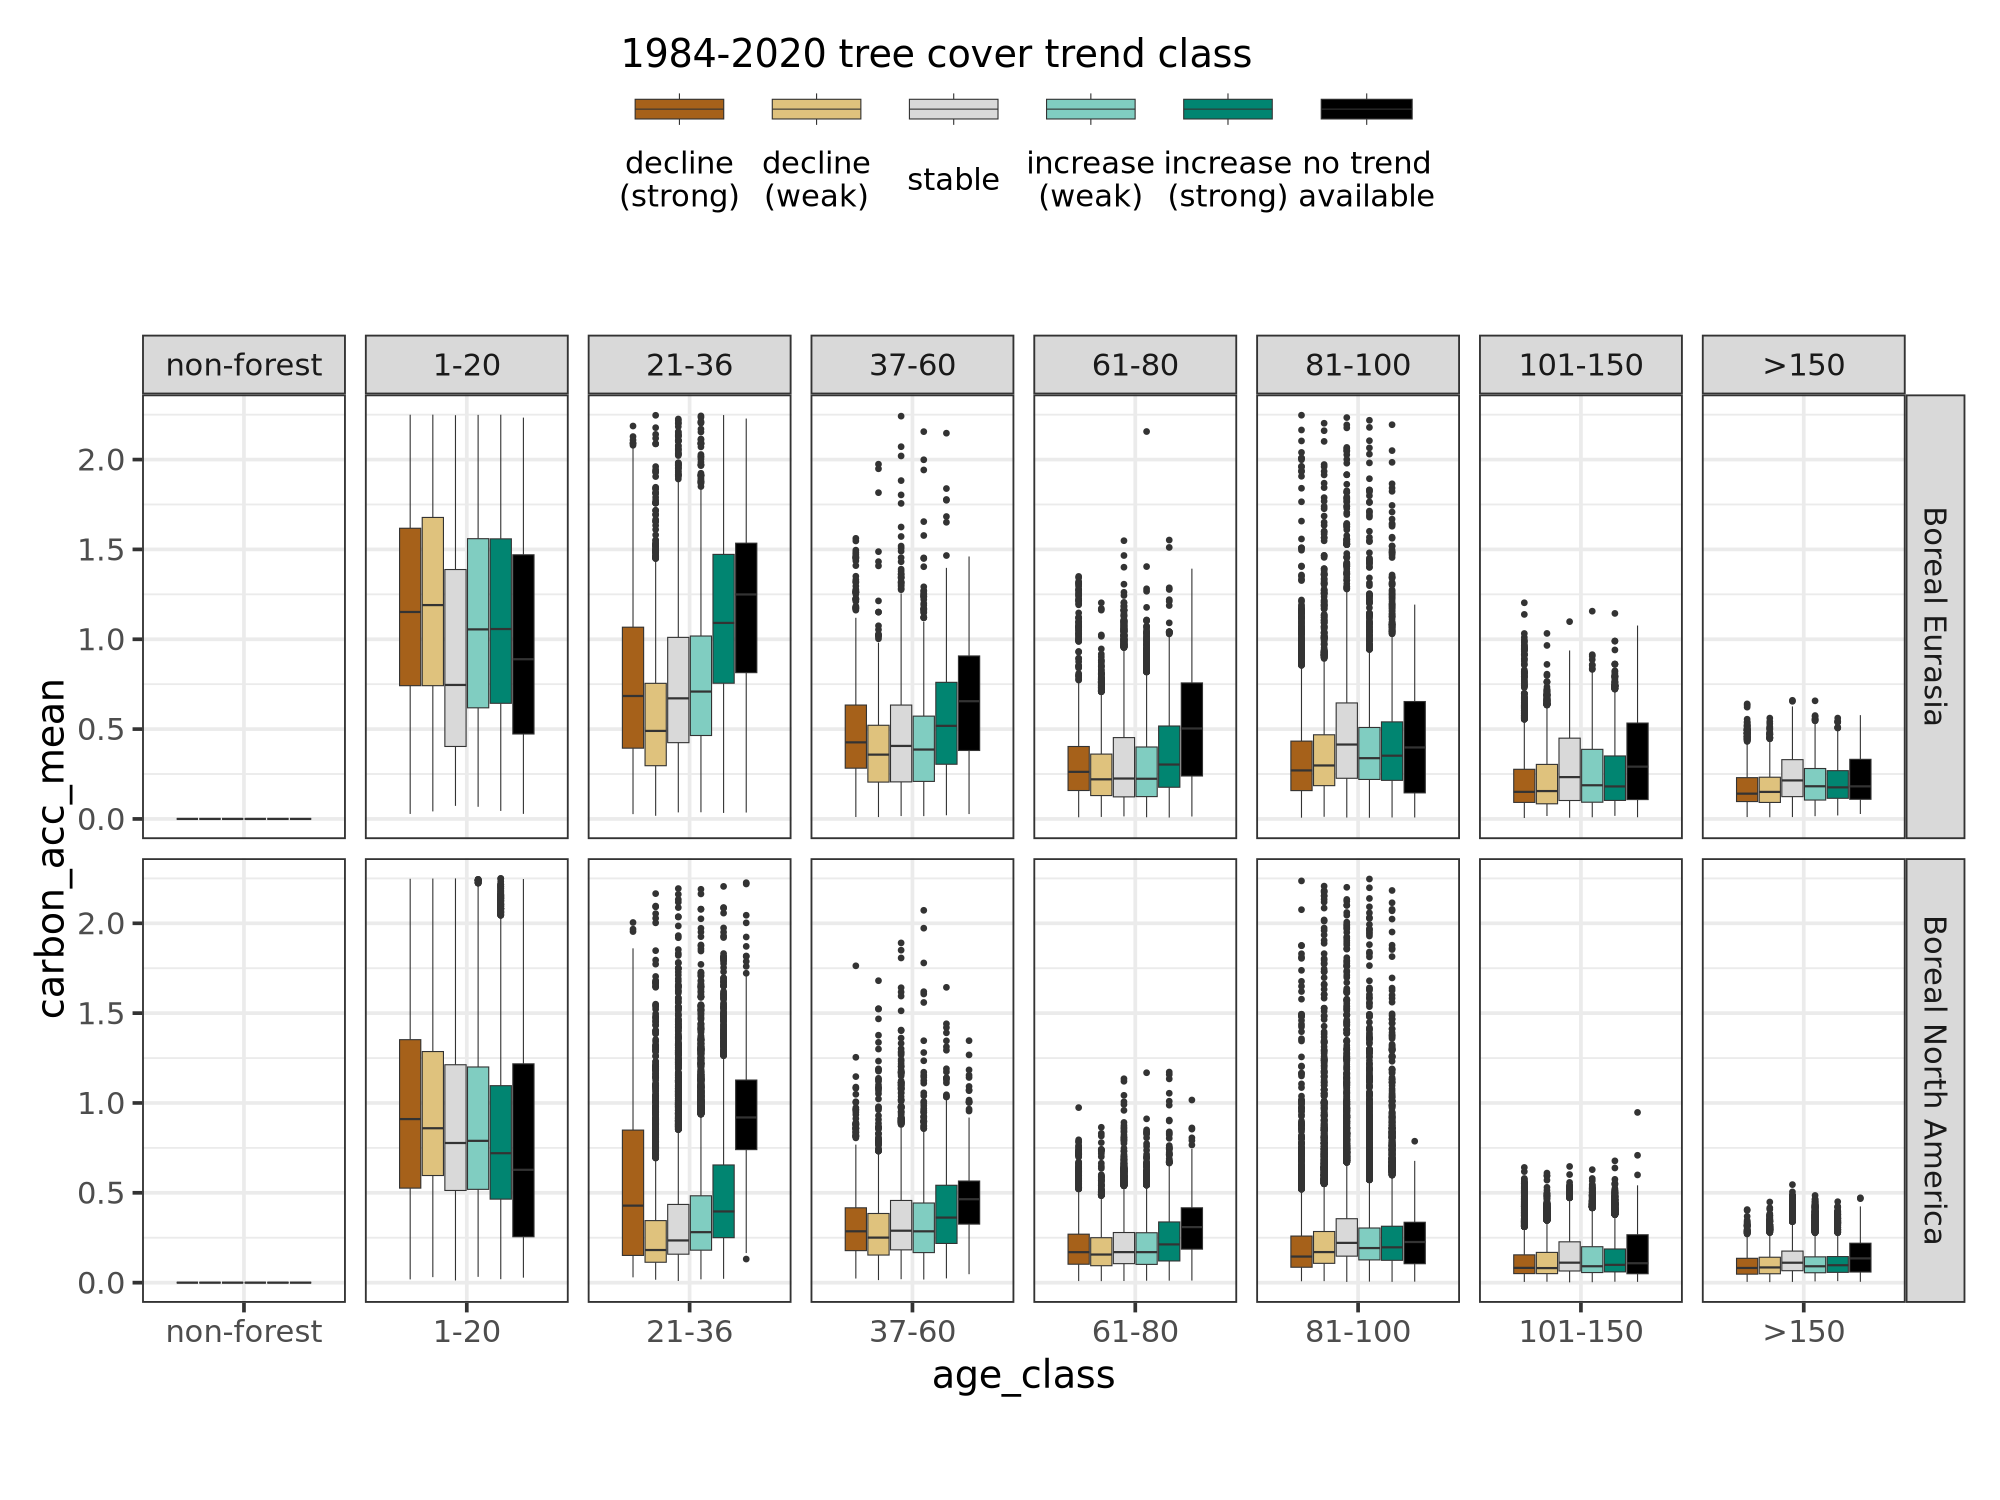

In [374]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 250)


ggplot(smry_boreal_only_df) +
    geom_boxplot(aes(x = age_class ,y = carbon_acc_mean, fill=trend_class),
                   position = position_dodge(width = 0.8), size=0.15, outlier.size = 0.25) +
    lims(y=c(0,2.25)) +
    theme_bw() + 
    geom_list_color_trend +
    facet_grid(ecoregions_REALM~age_class, scales='free')

# ggplot(summary_df %>% filter(age_class != 'non-forest')) +
#     geom_point(aes(x = age_cohort ,y = carbon_acc_mean, color=trend_class, group=ecoregions_ECO_NAME),
#                    position = position_dodge(width = 0.8), size=0.5) +
#     lims(y=c(0,3)) +
#     theme_bw() + 
#     geom_list_color_trend  +
#     facet_wrap(~trend_class, scales='free_y', ncol=3) 


# ggplot(summary_df %>% filter(age_class != 'non-forest')) +
#     geom_path(aes(x = age_class ,y = carbon_acc_mean, color=trend_class, group=trend_class),
#                    size=0.5) +
#     lims(y=c(0,3)) +
#     theme_bw() + 
#     geom_list_color_trend + 
#     facet_wrap(~ecoregions_ECO_NAME, scales='free_y', ncol=3) 

# ggplot(summary_df) +
#     geom_pointrange(aes(x = age_class ,y = carbon_acc_mean, ymin = carbon_acc_ci_lower_mean, ymax = carbon_acc_ci_upper_mean, group=trend_class, color=trend_class),
#                    position = position_dodge(width = 0.8)) +
#     #lims(y=c(0,10)) +
#     theme_bw() + 
#     geom_list_color_trend + 
#     facet_wrap(~ecoregions_ECO_NAME, scales='free_y') 

### Various totals  
C totals for ecoregion needs to come from from all the `summary_df` data frames - not yet ready



In [ ]:
# Just to check total
totals_ecoregion = summary_df %>% group_by(ecoregions_ECO_NAME) %>% summarize(Total_C = sum(total_carbon_Pg),
                                                       Total_C_ci_lwr = sum(total_carbon_Pg_ci_lower),
                                                       Total_C_ci_upr = sum(total_carbon_Pg_ci_upper),
                                                       )
totals_tile = summary_df %>% group_by(ID) %>% summarize(Total_C = sum(total_carbon_Pg),
                                                       Total_C_ci_lwr = sum(total_carbon_Pg_ci_lower),
                                                       Total_C_ci_upr = sum(total_carbon_Pg_ci_upper),
                                                       )
totals_decid = summary_df %>% group_by(deciduous_class) %>% summarize(Total_C = sum(total_carbon_Pg),
                                                       Total_C_ci_lwr = sum(total_carbon_Pg_ci_lower),
                                                       Total_C_ci_upr = sum(total_carbon_Pg_ci_upper),
                                                       )
totals_tile_decid = summary_df %>% group_by(ecoregions_ECO_NAME, ID, deciduous_class) %>% summarize(Total_C = sum(total_carbon_Pg),
                                                       Total_C_ci_lwr = sum(total_carbon_Pg_ci_lower),
                                                       Total_C_ci_upr = sum(total_carbon_Pg_ci_upper),
                                                       )
fraction_ecoregion_age = summary_df %>% 
    #drop_na() %>% 
    group_by(ecoregions_ECO_NAME, age_cohort) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
fraction_tile_age = summary_df %>% 
    #drop_na() %>% 
    group_by(ID, age_cohort) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
fraction_age_decid = summary_df %>% 
    #drop_na() %>% 
    group_by(deciduous_class, age_cohort) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
fraction_ecoregion_trend = summary_df %>% 
    group_by(ecoregions_ECO_NAME, trend_class) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
fraction_tile_trend = summary_df %>% 
    group_by(ID, trend_class) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
# ---wont work - b/c fraction calc'd sin smry by tile
# fraction_trend_decid = summary_df %>% 
#     group_by(trend_class, deciduous_class) %>% 
#     summarize(
#         Total_C = sum(total_carbon_Pg), 
#         Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
#         Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
#     )